# Benchmark definitivo en espectros excelentes no orientados: partición fija y cinco semillas

## Propósito

Este notebook evalúa la estabilidad de la CNN de referencia en la condición controlada `excellent_unoriented`. Las fuentes de validación y prueba se congelan una sola vez y permanecen formadas exclusivamente por espectros excelentes no orientados. Los espectros `fair_unoriented` elegibles se añaden únicamente al entrenamiento y se excluyen si su fuente aparece en validación o prueba.

## Pregunta experimental

¿Puede la arquitectura de referencia generalizar hacia fuentes minerales excelentes no vistas, y qué variación presenta al repetir el entrenamiento con cinco semillas?

## Principios del protocolo

- La unidad de separación es `source_id`, no el archivo individual.
- Ninguna fuente puede aparecer en más de una partición.
- Validación selecciona la mejor época; prueba se reserva para evaluación final.
- Se entrenan cinco modelos desde cero sobre la misma partición.
- Se informan métricas agregadas y rendimiento por clase.
- Al final se exporta un candidato de producción elegido solo por validación.

La finalidad no es afirmar que esta condición representa todos los escenarios Raman, sino establecer un benchmark controlado y reproducible.

Este notebook lee los TXT directamente desde los ZIP y muestra resultados inline. No exporta archivos ni crea carpetas de resultados.

## 1. Importaciones y reproducibilidad

Se cargan las bibliotecas necesarias para manipular los espectros, construir la red neuronal, entrenarla y calcular las métricas. También se fijan las semillas de Python, NumPy y TensorFlow para reducir las variaciones no controladas entre ejecuciones. La salida de la celda registra las versiones de software y la disponibilidad de GPU, información esencial para reproducir el experimento en otro equipo.

La reproducibilidad absoluta puede depender del hardware y de algunas operaciones internas de TensorFlow; por ello, el experimento se repite con cinco semillas y se informa la media y la desviación estándar, en lugar de basarse en una única ejecución.

In [1]:
import os, re, json, random, zipfile, platform, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from scipy.interpolate import interp1d
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    log_loss, accuracy_score, top_k_accuracy_score,
    precision_recall_fscore_support, classification_report,
    confusion_matrix, balanced_accuracy_score, matthews_corrcoef,
    roc_auc_score, average_precision_score,
)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("Python:", platform.python_version())
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Devices:", tf.config.list_physical_devices())
print("✓ Reproducibilidad configurada")

# Modo solo pantalla: no se escriben resultados en disco.
def _mostrar_en_pantalla(obj, destino=None, *args, **kwargs):
    nombre = str(destino) if destino is not None else "salida tabular"
    print(f"\n[SOLO PANTALLA] {nombre} | dimensiones: {getattr(obj, 'shape', None)}")
    try:
        display(obj if len(obj) <= 40 else obj.head(40))
    except Exception:
        print(obj)

pd.DataFrame.to_csv = lambda self, path_or_buf=None, *a, **k: _mostrar_en_pantalla(self, path_or_buf)
pd.Series.to_csv = lambda self, path_or_buf=None, *a, **k: _mostrar_en_pantalla(self, path_or_buf)
np.save = lambda destino, datos, *a, **k: _mostrar_en_pantalla(pd.DataFrame(np.atleast_1d(datos)), destino)
plt.savefig = lambda destino, *a, **k: print(f"[SOLO PANTALLA] Figura mostrada; no se guarda {destino}")
Path.write_text = lambda self, data, *a, **k: print(f"[SOLO PANTALLA] {self.name}:\n{str(data)[:4000]}") or len(str(data))

class ZipMember:
    """Referencia ligera a un TXT dentro de un ZIP, sin extracción a disco."""
    def __init__(self, archive_path, member):
        self.archive_path, self.member = Path(archive_path), member
    @property
    def name(self): return Path(self.member).name
    def read_bytes(self):
        with zipfile.ZipFile(self.archive_path) as zf: return zf.read(self.member)
    def __str__(self): return f"{self.archive_path.name}::{self.member}"
    def __repr__(self): return str(self)

def open_spectrum(member):
    import io
    return io.StringIO(member.read_bytes().decode("utf-8", errors="replace"))


Python: 3.11.15
TensorFlow: 2.21.0
NumPy: 2.4.6
Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
✓ Reproducibilidad configurada


## 2. Configuración del experimento

Esta celda centraliza las rutas, las semillas, el tamaño de la rejilla Raman, los criterios mínimos de inclusión, los hiperparámetros y la carpeta de resultados. Mantener estos valores reunidos permite auditar qué se ejecutó y evita cambios accidentales entre semillas.

Los nombres de variables y archivos permanecen en inglés porque forman parte del contrato computacional del notebook. Su significado metodológico se explica en español en cada sección.

In [2]:
EXCELLENT_ZIP_FILENAME = "excellent_unoriented.zip"
FAIR_ZIP_FILENAME = "fair_unoriented.zip"
EXCELLENT_ZIP_PATH = None  # Example: "/content/excellent_unoriented.zip"
FAIR_ZIP_PATH = None       # Example: "/content/fair_unoriented.zip"

WORK_DIR = Path("raman_excellent_unoriented_fixed_split_5_seeds")
EXTRACT_ROOT = WORK_DIR / "extracted"
RESULTS_DIR = WORK_DIR / "results"

MIN_CLASS_COUNT = 5
MIN_SOURCE_GROUPS = 3
REQUIRE_RELIABLE_SOURCE_IDS = True
N_GRID_POINTS = 512
COVERAGE_FRACTION = 0.95
MAX_EPOCHS = 150
SEEDS = [42, 123, 456, 789, 2026]
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
EARLY_STOPPING_PATIENCE = 15
LR_PATIENCE = 6

MAX_SHIFT_POINTS = 3
SHIFT_PROBABILITY = 0.70
MAX_NOISE_STD = 0.01
NOISE_PROBABILITY = 0.70


config = {
    "split_seed": SEED,
    "training_seeds": SEEDS,
    "archives": {
        "excellent_unoriented": EXCELLENT_ZIP_FILENAME,
        "fair_unoriented_training_only": FAIR_ZIP_FILENAME,
    },
    "evaluation_domain": "solo excellent_unoriented",
    "fair_data_policy": "solo entrenamiento; excluir fuentes presentes en validación/prueba excellent",
    "architecture": "pictured_cnn_conv16k21_conv32k11_conv64k5_dense2048",
    "min_class_count": MIN_CLASS_COUNT, "min_source_groups": MIN_SOURCE_GROUPS,
    "require_reliable_source_ids": REQUIRE_RELIABLE_SOURCE_IDS,
    "n_grid_points": N_GRID_POINTS, "coverage_fraction": COVERAGE_FRACTION,
    "max_epochs": MAX_EPOCHS, "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "lr_patience": LR_PATIENCE,
    "augmentation": {
        "training_only": True,
        "max_shift_points": MAX_SHIFT_POINTS,
        "shift_probability": SHIFT_PROBABILITY,
        "max_noise_std": MAX_NOISE_STD,
        "noise_probability": NOISE_PROBABILITY,
        "edge_handling": "valor del borde más próximo; sin desplazamiento circular ni relleno con ceros",
        "renormalize_after_augmentation": True,
    },
}
(RESULTS_DIR / "config.json").write_text(json.dumps(config, indent=2))
print("✓ Configuración mostrada en pantalla")


[SOLO PANTALLA] config.json:
{
  "split_seed": 42,
  "training_seeds": [
    42,
    123,
    456,
    789,
    2026
  ],
  "archives": {
    "excellent_unoriented": "excellent_unoriented.zip",
    "fair_unoriented_training_only": "fair_unoriented.zip"
  },
  "evaluation_domain": "solo excellent_unoriented",
  "fair_data_policy": "solo entrenamiento; excluir fuentes presentes en validaci\u00f3n/prueba excellent",
  "architecture": "pictured_cnn_conv16k21_conv32k11_conv64k5_dense2048",
  "min_class_count": 5,
  "min_source_groups": 3,
  "require_reliable_source_ids": true,
  "n_grid_points": 512,
  "coverage_fraction": 0.95,
  "max_epochs": 150,
  "batch_size": 32,
  "learning_rate": 0.001,
  "early_stopping_patience": 15,
  "lr_patience": 6,
  "augmentation": {
    "training_only": true,
    "max_shift_points": 3,
    "shift_probability": 0.7,
    "max_noise_std": 0.01,
    "noise_probability": 0.7,
    "edge_handling": "valor del borde m\u00e1s pr\u00f3ximo; sin desplazamiento circula

## 3. Localización, verificación y extracción de los datos

Se buscan los archivos ZIP requeridos en las ubicaciones admitidas y se comprueba que sean archivos válidos. Los espectros se extraen en directorios separados y cada registro conserva la procedencia del ZIP original. Además, se calcula una huella digital del contenido para identificar duplicados exactos: una copia se conserva y las repeticiones idénticas se excluyen del análisis.

Esta etapa no modifica los archivos originales. Su objetivo es producir un inventario trazable y evitar que copias idénticas inflen artificialmente el número de observaciones.

In [3]:
import hashlib
import shutil

def resolve_zip(filename, explicit_path=None):
    candidates = [Path(explicit_path)] if explicit_path is not None else [
        Path.cwd() / filename, Path("/content") / filename
    ]
    matches = [p.resolve() for p in candidates if p.exists()]
    if not matches:
        raise FileNotFoundError(
            f"No se encontró {filename}. Colóquelo junto al notebook, cárguelo en /content, "
            "o especifique su ruta en la celda de configuración."
        )
    return matches[0]

archive_specs = [
    ("excellent_unoriented", resolve_zip(EXCELLENT_ZIP_FILENAME, EXCELLENT_ZIP_PATH)),
    ("fair_unoriented", resolve_zip(FAIR_ZIP_FILENAME, FAIR_ZIP_PATH)),
]

file_entries = []
archive_file_counts = []
for dataset_subset, zip_path in archive_specs:
    with zipfile.ZipFile(zip_path) as archive:
        members = sorted(n for n in archive.namelist() if n.lower().endswith(".txt"))
    if not members:
        raise RuntimeError(f"{zip_path.name} no contiene espectros .txt.")
    subset_files = [ZipMember(zip_path, member) for member in members]
    file_entries.extend((path, dataset_subset) for path in subset_files)
    archive_file_counts.append({"dataset_subset": dataset_subset, "zip_filename": zip_path.name, "text_files": len(subset_files)})
    print(f"{dataset_subset}: {len(subset_files)} TXT leídos directamente de {zip_path.name}")

# Los duplicados exactos se detectan sobre los bytes internos, sin extraerlos.
seen_hashes, unique_entries, duplicate_rows = {}, [], []
for path, dataset_subset in file_entries:
    digest = hashlib.sha256(path.read_bytes()).hexdigest()
    if digest in seen_hashes:
        kept_path, kept_subset = seen_hashes[digest]
        duplicate_rows.append({"excluded_filepath": str(path), "excluded_subset": dataset_subset,
                               "kept_filepath": str(kept_path), "kept_subset": kept_subset, "sha256": digest})
    else:
        seen_hashes[digest] = (path, dataset_subset)
        unique_entries.append((path, dataset_subset))

duplicate_table = pd.DataFrame(duplicate_rows)
display(duplicate_table.head(40))
filepaths = [path for path, _ in unique_entries]
dataset_by_path = {str(path): subset for path, subset in unique_entries}
print("Archivos TXT únicos:", len(filepaths))
print("Duplicados exactos excluidos:", len(duplicate_rows))
print("✓ ZIP leídos directamente; no se crearon carpetas de extracción")


excellent_unoriented: 11415 TXT leídos directamente de excellent_unoriented.zip
fair_unoriented: 2951 TXT leídos directamente de fair_unoriented.zip


""


Archivos TXT únicos: 14366
Duplicados exactos excluidos: 0
✓ ZIP leídos directamente; no se crearon carpetas de extracción


## 4. Lectura de espectros y auditoría de identificadores RRUFF

El analizador extrae los pares numéricos de desplazamiento Raman e intensidad, ordena las coordenadas y verifica que cada espectro tenga suficientes puntos finitos, un eje no degenerado y una señal utilizable. Los archivos que no cumplen estos requisitos quedan registrados con el motivo del rechazo.

También se recupera el identificador de fuente RRUFF —por ejemplo, `R040063`— tanto del nombre del archivo como de su cabecera. Este identificador representa la muestra o fuente mineral y se utiliza como unidad de agrupación. La auditoría permite detectar identificadores ausentes, ambiguos o asociados a etiquetas incompatibles antes de construir las particiones, reduciendo así el riesgo de fuga de información.

In [4]:
NUMBER = re.compile(r"[-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[Ee][-+]?\d+)?")
RRUFF_ID = re.compile(r"(?<![A-Za-z0-9])R\d{6,8}(?!\d)", re.IGNORECASE)

def mineral_from_filename(path):
    label = path.name.split("__")[0].strip()
    return label.replace("_", " ")

def unique_rruff_ids(text):
    return sorted({m.upper() for m in RRUFF_ID.findall(text)})

def load_spectrum_and_header(path):
    pairs, header_lines = [], []
    try:
        with open_spectrum(path) as handle:
            for line in handle:
                if line.lstrip().startswith("##"):
                    header_lines.append(line.strip())
                    continue
                if not line.strip():
                    continue
                values = NUMBER.findall(line)
                if len(values) >= 2:
                    try:
                        pairs.append((float(values[0]), float(values[1])))
                    except ValueError:
                        pass
        if len(pairs) < 10:
            return None, header_lines, "menos de 10 pares numéricos"
        arr = np.asarray(pairs, dtype=np.float64)
        arr = arr[np.isfinite(arr[:, 0])]
        if len(arr) < 10:
            return None, header_lines, "muy pocas coordenadas Raman finitas"
        if not np.isfinite(arr[:, 1]).all():
            return None, header_lines, "intensidades no finitas"
        frame = pd.DataFrame({"shift": arr[:, 0], "intensity": arr[:, 1]})
        frame = frame.groupby("shift", as_index=False)["intensity"].mean().sort_values("shift")
        if len(frame) < 10 or frame["shift"].iloc[-1] <= frame["shift"].iloc[0]:
            return None, header_lines, "eje Raman degenerado"
        if np.max(np.abs(frame["intensity"].to_numpy())) <= 1e-12:
            return None, header_lines, "espectro plano o prácticamente nulo"
        spectrum = (frame["shift"].to_numpy(), frame["intensity"].to_numpy())
        return spectrum, header_lines, None
    except Exception as exc:
        return None, header_lines, f"error de lectura: {type(exc).__name__}"

records, parsed = [], {}
for i, path in enumerate(filepaths):
    dataset_subset = dataset_by_path[str(path)]
    result, header_lines, reason = load_spectrum_and_header(path)
    filename_ids = unique_rruff_ids(path.name)
    header_ids = unique_rruff_ids("\n".join(header_lines))
    candidate_ids = sorted(set(filename_ids) | set(header_ids))
    conflict = bool(filename_ids and header_ids and set(filename_ids) != set(header_ids))
    resolved_source_id = candidate_ids[0] if len(candidate_ids) == 1 and not conflict else None
    if conflict:
        source_status = "filename_header_conflict"
    elif len(candidate_ids) == 0:
        source_status = "missing"
    elif len(candidate_ids) > 1:
        source_status = "multiple_candidates"
    elif filename_ids and header_ids:
        source_status = "filename_header_agree"
    elif filename_ids:
        source_status = "filename_only"
    else:
        source_status = "header_only"

    label = mineral_from_filename(path)
    record = {
        "spectrum_id": f"S{i:06d}", "filepath": str(path), "filename": path.name,
        "dataset_subset": dataset_subset, "label": label, "accepted_parse": result is not None, "rejection_reason": reason,
        "source_id_filename": "|".join(filename_ids),
        "source_id_header": "|".join(header_ids),
        "source_id": resolved_source_id,
        "source_id_status": source_status,
    }
    if result is not None:
        shift, intensity = result
        record.update(n_points=len(shift), min_shift=float(shift.min()), max_shift=float(shift.max()))
        parsed[record["spectrum_id"]] = (shift, intensity)
    records.append(record)

manifest = pd.DataFrame(records)
source_audit = manifest[[
    "spectrum_id", "filepath", "dataset_subset", "label", "source_id_filename", "source_id_header",
    "source_id", "source_id_status", "accepted_parse"
]].copy()
source_audit.to_csv(RESULTS_DIR / "source_id_audit.csv", index=False)
manifest.to_csv(RESULTS_DIR / "parsing_manifest.csv", index=False)

display(manifest.groupby("dataset_subset")["accepted_parse"].agg(files="size", parsed="sum"))
print("Archivos leídos correctamente:", int(manifest["accepted_parse"].sum()))
print("Archivos rechazados durante la lectura:", int((~manifest["accepted_parse"]).sum()))
display(manifest["source_id_status"].value_counts(dropna=False).rename("count").to_frame())
display(manifest.loc[~manifest["accepted_parse"], "rejection_reason"].value_counts().rename("count").to_frame())
print("✓ Manifiesto de lectura y auditoría de identificadores de fuente guardados")



[SOLO PANTALLA] raman_excellent_unoriented_fixed_split_5_seeds/results/source_id_audit.csv | dimensiones: (14366, 9)


,spectrum_id,filepath,dataset_subset,label,source_id_filename,source_id_header,source_id,source_id_status,accepted_parse
0,S000000,excellent_unoriented.zip::Abellaite__R250095__...,excellent_unoriented,Abellaite,R250095,R250095,R250095,filename_header_agree,True
1,S000001,excellent_unoriented.zip::Abellaite__R250095__...,excellent_unoriented,Abellaite,R250095,R250095,R250095,filename_header_agree,True
2,S000002,excellent_unoriented.zip::Abelsonite__R070007_...,excellent_unoriented,Abelsonite,R070007,R070007,R070007,filename_header_agree,True
3,S000003,excellent_unoriented.zip::Abelsonite__R070007_...,excellent_unoriented,Abelsonite,R070007,R070007,R070007,filename_header_agree,True
4,S000004,excellent_unoriented.zip::Abhurite__R060227__R...,excellent_unoriented,Abhurite,R060227,R060227,R060227,filename_header_agree,True
5,S000005,excellent_unoriented.zip::Abhurite__R060227__R...,excellent_unoriented,Abhurite,R060227,R060227,R060227,filename_header_agree,True
6,S000006,excellent_unoriented.zip::Abhurite__R060227__R...,excellent_unoriented,Abhurite,R060227,R060227,R060227,filename_header_agree,True
7,S000007,excellent_unoriented.zip::Abhurite__R060227__R...,excellent_unoriented,Abhurite,R060227,R060227,R060227,filename_header_agree,True
8,S000008,excellent_unoriented.zip::Actinolite__R040063_...,excellent_unoriented,Actinolite,R040063,R040063,R040063,filename_header_agree,True
9,S000009,excellent_unoriented.zip::Actinolite__R040063_...,excellent_unoriented,Actinolite,R040063,R040063,R040063,filename_header_agree,True



[SOLO PANTALLA] raman_excellent_unoriented_fixed_split_5_seeds/results/parsing_manifest.csv | dimensiones: (14366, 14)


,spectrum_id,filepath,filename,dataset_subset,label,accepted_parse,rejection_reason,source_id_filename,source_id_header,source_id,source_id_status,n_points,min_shift,max_shift
0,S000000,excellent_unoriented.zip::Abellaite__R250095__...,Abellaite__R250095__Raman__532______Raman_Data...,excellent_unoriented,Abellaite,True,None,R250095,R250095,R250095,filename_header_agree,3209,50.00000,1301.270
1,S000001,excellent_unoriented.zip::Abellaite__R250095__...,Abellaite__R250095__Raman__532______Raman_Data...,excellent_unoriented,Abellaite,True,None,R250095,R250095,R250095,filename_header_agree,3209,50.00000,1301.270
2,S000002,excellent_unoriented.zip::Abelsonite__R070007_...,Abelsonite__R070007__Raman__532______Raman_Dat...,excellent_unoriented,Abelsonite,True,None,R070007,R070007,R070007,filename_header_agree,2312,153.55700,1267.727
3,S000003,excellent_unoriented.zip::Abelsonite__R070007_...,Abelsonite__R070007__Raman__532______Raman_Dat...,excellent_unoriented,Abelsonite,True,None,R070007,R070007,R070007,filename_header_agree,2379,153.55700,1300.029
4,S000004,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__532______Raman_Data_...,excellent_unoriented,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2367,163.43140,1304.119
5,S000005,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__532______Raman_Data_...,excellent_unoriented,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2515,92.07813,1304.119
6,S000006,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__780______Raman_Data_...,excellent_unoriented,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2476,91.82715,1285.066
7,S000007,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__780______Raman_Data_...,excellent_unoriented,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2476,91.82715,1285.066
8,S000008,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__514______Raman_Dat...,excellent_unoriented,Actinolite,True,None,R040063,R040063,R040063,filename_header_agree,1077,139.24300,1513.235
9,S000009,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__514______Raman_Dat...,excellent_unoriented,Actinolite,True,None,R040063,R040063,R040063,filename_header_agree,1077,139.24300,1513.235


,files,parsed
dataset_subset,,
excellent_unoriented,11415,11415
fair_unoriented,2951,2951


Archivos leídos correctamente: 14366
Archivos rechazados durante la lectura: 0


,count
source_id_status,
filename_header_agree,13017
filename_header_conflict,1212
missing,128
header_only,8
filename_only,1


,count
rejection_reason,


✓ Manifiesto de lectura y auditoría de identificadores de fuente guardados


## 5. Definición de la rejilla Raman común y control de cobertura

Las CNN requieren vectores de igual longitud. Por ello, se determina un intervalo Raman común a partir del conjunto de referencia y se crea una rejilla uniforme. Un espectro solo se acepta si su rango medido cubre completamente ese intervalo; no se extrapolan regiones inexistentes.

El gráfico de cobertura permite comprobar visualmente los límites mínimos y máximos disponibles. La interpolación posterior coloca todos los espectros sobre las mismas coordenadas, de modo que una posición de entrada represente el mismo desplazamiento Raman en todas las observaciones.

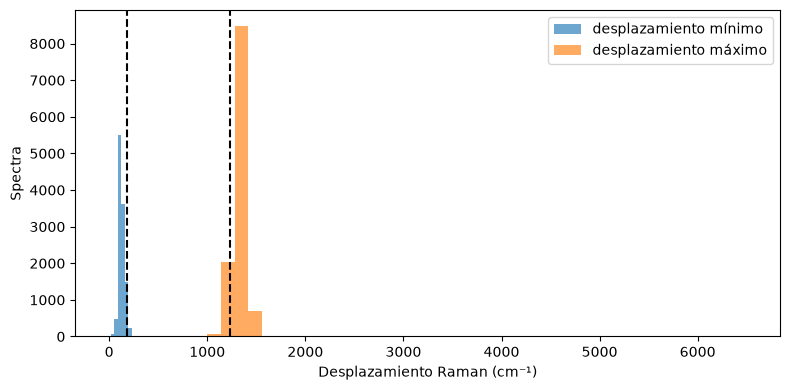

Intervalo seleccionado: 180.71–1236.15 cm⁻¹
Grid: 512 puntos; separación 2.065 cm⁻¹


,parsed,complete_coverage
dataset_subset,,
excellent_unoriented,11415,10299
fair_unoriented,2951,2338


Espectros con cobertura completa: 12637


In [5]:
ok = manifest[manifest["accepted_parse"]].copy()
ok_excellent = ok[ok["dataset_subset"] == "excellent_unoriented"].copy()
if ok_excellent.empty:
    raise RuntimeError("No se pudo leer correctamente ningún espectro excellent-unoriented.")
LOWER_LIMIT = float(np.quantile(ok_excellent["min_shift"], COVERAGE_FRACTION))
UPPER_LIMIT = float(np.quantile(ok_excellent["max_shift"], 1 - COVERAGE_FRACTION))
if LOWER_LIMIT >= UPPER_LIMIT:
    raise RuntimeError("No se encontró un intervalo Raman común válido. Revise el gráfico de cobertura y los archivos de datos.")
target_grid = np.linspace(LOWER_LIMIT, UPPER_LIMIT, N_GRID_POINTS, dtype=np.float32)

coverage_ok = (ok["min_shift"] <= LOWER_LIMIT) & (ok["max_shift"] >= UPPER_LIMIT)
coverage_ids = set(ok.loc[coverage_ok, "spectrum_id"])
manifest["accepted_coverage"] = manifest["spectrum_id"].isin(coverage_ids)
mask = manifest["accepted_parse"] & ~manifest["accepted_coverage"]
manifest.loc[mask, "rejection_reason"] = "cobertura insuficiente del intervalo común"

plt.figure(figsize=(8, 4))
plt.hist(ok_excellent["min_shift"], bins=40, alpha=0.65, label="desplazamiento mínimo")
plt.hist(ok_excellent["max_shift"], bins=40, alpha=0.65, label="desplazamiento máximo")
plt.axvline(LOWER_LIMIT, color="black", linestyle="--")
plt.axvline(UPPER_LIMIT, color="black", linestyle="--")
plt.xlabel("Desplazamiento Raman (cm⁻¹)"); plt.ylabel("Spectra"); plt.legend(); plt.tight_layout(); plt.show()

print(f"Intervalo seleccionado: {LOWER_LIMIT:.2f}–{UPPER_LIMIT:.2f} cm⁻¹")
print(f"Grid: {N_GRID_POINTS} puntos; separación {target_grid[1]-target_grid[0]:.3f} cm⁻¹")
display(manifest[manifest["accepted_parse"]].groupby("dataset_subset")["accepted_coverage"].agg(parsed="size", complete_coverage="sum"))
print("Espectros con cobertura completa:", len(coverage_ids))


## 6. Armonización, normalización y selección de clases auditables

Cada espectro aceptado se interpola linealmente sobre la rejilla común y se normaliza dividiendo sus intensidades por el máximo valor absoluto. Esta normalización conserva la forma relativa del espectro y reduce las diferencias de escala debidas a la adquisición. Se rechazan divisores nulos o no finitos.

Después se excluyen fuentes sin identificador inequívoco y se ponen en cuarentena los identificadores asociados a más de una etiqueta mineral. Solo se retienen clases con soporte suficiente en número de espectros y en fuentes independientes para construir entrenamiento, validación y prueba por grupos. Los CSV exportados documentan qué se incluyó, qué se excluyó y por qué.

In [6]:
X_list, labels, metadata_rows = [], [], []
for row in manifest[manifest["accepted_coverage"]].itertuples():
    shift, intensity = parsed[row.spectrum_id]
    interpolated = np.interp(target_grid, shift, intensity).astype(np.float32)
    scale = float(np.max(np.abs(interpolated)))
    if not np.isfinite(scale) or scale <= 1e-12:
        manifest.loc[manifest["spectrum_id"] == row.spectrum_id, "accepted_coverage"] = False
        manifest.loc[manifest["spectrum_id"] == row.spectrum_id, "rejection_reason"] = "divisor de normalización no válido"
        continue
    normalized = (interpolated / scale).astype(np.float32)
    if not np.isfinite(normalized).all():
        raise AssertionError(f"Valores normalizados no finitos en {row.filepath}")
    X_list.append(normalized); labels.append(row.label)
    metadata_rows.append({
        "spectrum_id": row.spectrum_id, "filepath": row.filepath, "filename": row.filename,
        "dataset_subset": row.dataset_subset, "label": row.label, "source_id": row.source_id, "source_id_status": row.source_id_status,
    })

X_all = np.asarray(X_list, dtype=np.float32)
metadata_all = pd.DataFrame(metadata_rows)
missing_source = metadata_all["source_id"].isna()
n_unresolved = int(missing_source.sum())
if n_unresolved:
    unresolved = metadata_all.loc[missing_source, [
        "spectrum_id", "filepath", "filename", "dataset_subset", "label", "source_id_status"
    ]].copy()
    unresolved.to_csv(RESULTS_DIR / "excluded_unresolved_source_ids.csv", index=False)
    print(f"Se ponen en cuarentena {n_unresolved} espectros utilizables sin un identificador de fuente resuelto de manera inequívoca.")
    display(unresolved.head(30))

if REQUIRE_RELIABLE_SOURCE_IDS:
    resolved_mask = (~missing_source).to_numpy()
    X_all = X_all[resolved_mask]
    metadata_all = metadata_all.loc[~missing_source].reset_index(drop=True)

if len(metadata_all) == 0:
    raise RuntimeError(
        "No spectra with reliable source IDs remain. Review source_id_audit.csv and "
        "excluded_unresolved_source_ids.csv; group-aware evaluation cannot run."
    )

source_label_counts = metadata_all.groupby("source_id")["label"].nunique()
colliding_sources = source_label_counts[source_label_counts > 1]
n_conflicting_sources = int(len(colliding_sources))
n_conflicting_spectra = 0
if n_conflicting_sources:
    conflict_mask = metadata_all["source_id"].isin(colliding_sources.index)
    collision_rows = metadata_all.loc[conflict_mask].copy()
    n_conflicting_spectra = int(conflict_mask.sum())
    collision_rows.to_csv(RESULTS_DIR / "source_label_conflicts.csv", index=False)
    conflict_summary = (collision_rows.groupby("source_id")
                        .agg(n_labels=("label", "nunique"),
                             labels=("label", lambda s: " | ".join(sorted(set(s)))),
                             n_spectra=("spectrum_id", "size"))
                        .reset_index().sort_values(["n_labels", "n_spectra"], ascending=False))
    conflict_summary.to_csv(RESULTS_DIR / "source_label_conflict_summary.csv", index=False)
    print(f"Se ponen en cuarentena {n_conflicting_spectra} espectros procedentes de {n_conflicting_sources} identificadores de fuente asociados a varias etiquetas.")
    display(conflict_summary.head(30))
    clean_mask = (~conflict_mask).to_numpy()
    X_all = X_all[clean_mask]
    metadata_all = metadata_all.loc[~conflict_mask].reset_index(drop=True)

if len(metadata_all) == 0:
    raise RuntimeError(
        "No quedan grupos de fuentes inequívocos después de aislar los conflictos entre etiquetas. "
        "Revise source_label_conflict_summary.csv; no es posible realizar una evaluación agrupada por fuentes."
    )

excellent_clean = metadata_all[metadata_all["dataset_subset"] == "excellent_unoriented"]
class_spectrum_counts = excellent_clean["label"].value_counts()
class_source_counts = excellent_clean.groupby("label")["source_id"].nunique()
class_audit = pd.concat([
    class_spectrum_counts.rename("usable_spectra"),
    class_source_counts.rename("distinct_sources"),
], axis=1).fillna(0)
class_audit["retained"] = (
    (class_audit["usable_spectra"] >= MIN_CLASS_COUNT) &
    (class_audit["distinct_sources"] >= MIN_SOURCE_GROUPS)
)
class_audit["exclusion_reason"] = np.where(
    class_audit["usable_spectra"] < MIN_CLASS_COUNT, "too_few_spectra",
    np.where(class_audit["distinct_sources"] < MIN_SOURCE_GROUPS, "fewer_than_3_sources", "")
)
class_audit.to_csv(RESULTS_DIR / "class_source_audit.csv")

valid_classes = set(class_audit.index[class_audit["retained"]])
if not valid_classes:
    raise RuntimeError(
        "Ninguna clase mineral conserva al menos tres grupos de fuentes inequívocos después de la auditoría. "
        "Revise class_source_audit.csv; estos identificadores no permiten un experimento de entrenamiento, validación y prueba agrupado por fuentes."
    )
keep = metadata_all["label"].isin(valid_classes).to_numpy()
X = X_all[keep]
metadata = metadata_all.loc[keep].reset_index(drop=True)

encoder = LabelEncoder()
y = encoder.fit_transform(metadata["label"]).astype(np.int32)
class_names = encoder.classes_
n_classes = len(class_names)
X_cnn = X[..., np.newaxis].astype(np.float32)

assert len(X_cnn) == len(y) == len(metadata)
assert X_cnn.shape == (len(X), N_GRID_POINTS, 1)
assert X_cnn.dtype == np.float32 and np.isfinite(X_cnn).all()
assert metadata["source_id"].notna().all()
assert metadata.groupby("source_id")["label"].nunique().max() == 1
assert metadata[metadata["dataset_subset"] == "excellent_unoriented"].groupby("label")["source_id"].nunique().min() >= MIN_SOURCE_GROUPS

manifest.to_csv(RESULTS_DIR / "final_manifest.csv", index=False)
pd.DataFrame({"class_index": np.arange(n_classes), "label": class_names}).to_csv(
    RESULTS_DIR / "label_mapping.csv", index=False
)

display(metadata.groupby("dataset_subset").agg(spectra=("spectrum_id", "size"), sources=("source_id", "nunique")))
print("Espectros utilizables tras filtrar clases y fuentes:", len(X))
print("Espectros utilizables excluidos por identificador de fuente no resuelto:", n_unresolved)
print("Espectros excluidos por conflicto entre fuente y etiqueta:", n_conflicting_spectra)
print("Identificadores de fuente conflictivos puestos en cuarentena:", n_conflicting_sources)
print("Clases conservadas:", n_classes)
print("Fuentes distintas conservadas:", metadata["source_id"].nunique())
print("Clases excluidas:", int((~class_audit["retained"]).sum()))
print("✓ Datos armonizados y grupos de fuentes fiables establecidos")



[SOLO PANTALLA] raman_excellent_unoriented_fixed_split_5_seeds/results/excluded_unresolved_source_ids.csv | dimensiones: (1175, 6)


,spectrum_id,filepath,filename,dataset_subset,label,source_id_status
56,S000062,excellent_unoriented.zip::Adelite__R060687__Ra...,Adelite__R060687__Raman__532______Raman_Data_P...,excellent_unoriented,Adelite,filename_header_conflict
57,S000063,excellent_unoriented.zip::Adelite__R060687__Ra...,Adelite__R060687__Raman__532______Raman_Data_R...,excellent_unoriented,Adelite,filename_header_conflict
58,S000065,excellent_unoriented.zip::Adelite__R060687__Ra...,Adelite__R060687__Raman__785______Raman_Data_R...,excellent_unoriented,Adelite,filename_header_conflict
94,S000108,excellent_unoriented.zip::Aeschynite-(Y)__R080...,Aeschynite-(Y)__R080045__Raman__532______Raman...,excellent_unoriented,Aeschynite-(Y),filename_header_conflict
95,S000109,excellent_unoriented.zip::Aeschynite-(Y)__R080...,Aeschynite-(Y)__R080045__Raman__532______Raman...,excellent_unoriented,Aeschynite-(Y),filename_header_conflict
104,S000119,excellent_unoriented.zip::Afwillite__R070296__...,Afwillite__R070296__Raman__532______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict
105,S000120,excellent_unoriented.zip::Afwillite__R070296__...,Afwillite__R070296__Raman__532______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict
106,S000123,excellent_unoriented.zip::Afwillite__R080022__...,Afwillite__R080022__Raman__532______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict
107,S000124,excellent_unoriented.zip::Afwillite__R080022__...,Afwillite__R080022__Raman__532______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict
108,S000125,excellent_unoriented.zip::Afwillite__R080022__...,Afwillite__R080022__Raman__780______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict


Se ponen en cuarentena 1175 espectros utilizables sin un identificador de fuente resuelto de manera inequívoca.


,spectrum_id,filepath,filename,dataset_subset,label,source_id_status
56,S000062,excellent_unoriented.zip::Adelite__R060687__Ra...,Adelite__R060687__Raman__532______Raman_Data_P...,excellent_unoriented,Adelite,filename_header_conflict
57,S000063,excellent_unoriented.zip::Adelite__R060687__Ra...,Adelite__R060687__Raman__532______Raman_Data_R...,excellent_unoriented,Adelite,filename_header_conflict
58,S000065,excellent_unoriented.zip::Adelite__R060687__Ra...,Adelite__R060687__Raman__785______Raman_Data_R...,excellent_unoriented,Adelite,filename_header_conflict
94,S000108,excellent_unoriented.zip::Aeschynite-(Y)__R080...,Aeschynite-(Y)__R080045__Raman__532______Raman...,excellent_unoriented,Aeschynite-(Y),filename_header_conflict
95,S000109,excellent_unoriented.zip::Aeschynite-(Y)__R080...,Aeschynite-(Y)__R080045__Raman__532______Raman...,excellent_unoriented,Aeschynite-(Y),filename_header_conflict
104,S000119,excellent_unoriented.zip::Afwillite__R070296__...,Afwillite__R070296__Raman__532______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict
105,S000120,excellent_unoriented.zip::Afwillite__R070296__...,Afwillite__R070296__Raman__532______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict
106,S000123,excellent_unoriented.zip::Afwillite__R080022__...,Afwillite__R080022__Raman__532______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict
107,S000124,excellent_unoriented.zip::Afwillite__R080022__...,Afwillite__R080022__Raman__532______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict
108,S000125,excellent_unoriented.zip::Afwillite__R080022__...,Afwillite__R080022__Raman__780______Raman_Data...,excellent_unoriented,Afwillite,filename_header_conflict



[SOLO PANTALLA] raman_excellent_unoriented_fixed_split_5_seeds/results/source_label_conflicts.csv | dimensiones: (8, 7)


...

,spectrum_id,filepath,filename,dataset_subset,label,accepted_parse,rejection_reason,source_id_filename,source_id_header,source_id,source_id_status,n_points,min_shift,max_shift,accepted_coverage
0,S000000,excellent_unoriented.zip::Abellaite__R250095__...,Abellaite__R250095__Raman__532______Raman_Data...,excellent_unoriented,Abellaite,True,None,R250095,R250095,R250095,filename_header_agree,3209,50.00000,1301.270,True
1,S000001,excellent_unoriented.zip::Abellaite__R250095__...,Abellaite__R250095__Raman__532______Raman_Data...,excellent_unoriented,Abellaite,True,None,R250095,R250095,R250095,filename_header_agree,3209,50.00000,1301.270,True
2,S000002,excellent_unoriented.zip::Abelsonite__R070007_...,Abelsonite__R070007__Raman__532______Raman_Dat...,excellent_unoriented,Abelsonite,True,None,R070007,R070007,R070007,filename_header_agree,2312,153.55700,1267.727,True
3,S000003,excellent_unoriented.zip::Abelsonite__R070007_...,Abelsonite__R070007__Raman__532______Raman_Dat...,excellent_unoriented,Abelsonite,True,None,R070007,R070007,R070007,filename_header_agree,2379,153.55700,1300.029,True
4,S000004,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__532______Raman_Data_...,excellent_unoriented,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2367,163.43140,1304.119,True
5,S000005,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__532______Raman_Data_...,excellent_unoriented,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2515,92.07813,1304.119,True
6,S000006,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__780______Raman_Data_...,excellent_unoriented,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2476,91.82715,1285.066,True
7,S000007,excellent_unoriented.zip::Abhurite__R060227__R...,Abhurite__R060227__Raman__780______Raman_Data_...,excellent_unoriented,Abhurite,True,None,R060227,R060227,R060227,filename_header_agree,2476,91.82715,1285.066,True
8,S000008,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__514______Raman_Dat...,excellent_unoriented,Actinolite,True,None,R040063,R040063,R040063,filename_header_agree,1077,139.24300,1513.235,True
9,S000009,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__514______Raman_Dat...,excellent_unoriented,Actinolite,True,None,R040063,R040063,R040063,filename_header_agree,1077,139.24300,1513.235,True



[SOLO PANTALLA] raman_excellent_unoriented_fixed_split_5_seeds/results/label_mapping.csv | dimensiones: (208, 2)


,class_index,label
0,0,Actinolite
1,1,Adamite
2,2,Aegirine
3,3,Agardite-(Y)
4,4,Albite
5,5,Alluaudite
6,6,Almandine
7,7,Alum-(K)
8,8,Andalusite
9,9,Andradite


,spectra,sources
dataset_subset,,
excellent_unoriented,3441,912
fair_unoriented,337,135


Espectros utilizables tras filtrar clases y fuentes: 3778
Espectros utilizables excluidos por identificador de fuente no resuelto: 1175
Espectros excluidos por conflicto entre fuente y etiqueta: 8
Identificadores de fuente conflictivos puestos en cuarentena: 2
Clases conservadas: 208
Fuentes distintas conservadas: 947
Clases excluidas: 1543
✓ Datos armonizados y grupos de fuentes fiables establecidos


## 7. Inspección descriptiva de los datos procesados

Los gráficos resumen el desbalance entre clases y muestran ejemplos de espectros ya armonizados. El histograma indica cuántos espectros aporta cada mineral, mientras que las curvas permiten comprobar que la rejilla y la normalización producen señales coherentes.

Estas visualizaciones son exclusivamente descriptivas: no intervienen en la selección de la partición, de la semilla ni del modelo, y por tanto no introducen información del conjunto de prueba en el entrenamiento.

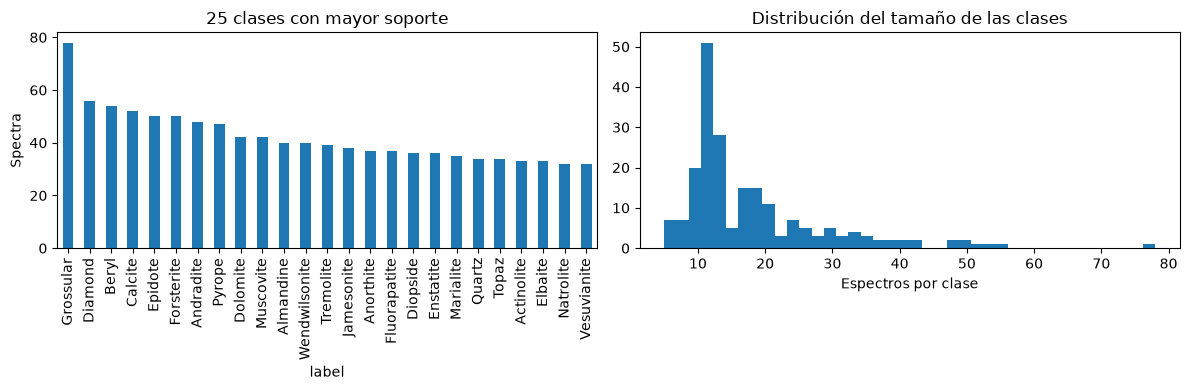

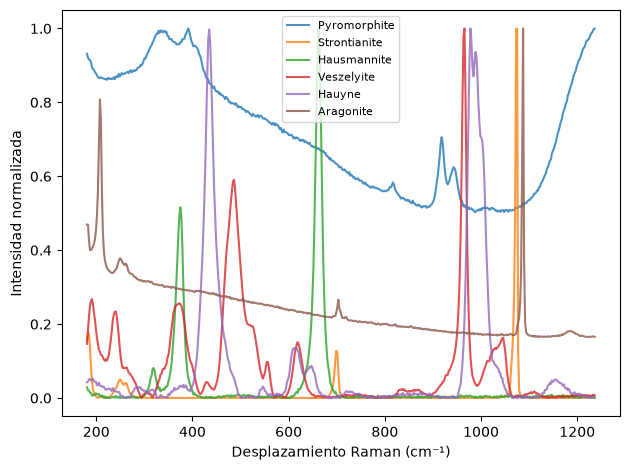

In [7]:
counts = metadata["label"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts.head(25).plot.bar(ax=axes[0]); axes[0].set_title("25 clases con mayor soporte"); axes[0].set_ylabel("Spectra")
axes[1].hist(counts.values, bins=40); axes[1].set_title("Distribución del tamaño de las clases"); axes[1].set_xlabel("Espectros por clase")
plt.tight_layout(); plt.show()

rng = np.random.default_rng(SEED)
for idx in rng.choice(len(X), size=min(6, len(X)), replace=False):
    plt.plot(target_grid, X[idx], alpha=0.8, label=metadata.loc[idx, "label"])
plt.xlabel("Desplazamiento Raman (cm⁻¹)"); plt.ylabel("Intensidad normalizada")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()


## 8. Partición por fuente en el dominio excelente e incorporación segura de datos fair

Para cada clase retenida, las fuentes `excellent_unoriented` se distribuyen entre entrenamiento, validación y prueba sin fraccionar una misma fuente. De este modo, varios espectros de la misma muestra no pueden aparecer simultáneamente a ambos lados de la evaluación.

Después se añaden al entrenamiento los espectros `fair_unoriented` compatibles. Si una fuente fair coincide con una fuente excelente reservada para validación o prueba, se excluye. Así, el conjunto de evaluación continúa siendo estrictamente excelente no orientado y la información adicional solo amplía el entrenamiento.

In [8]:
def classwise_group_split(metadata_subset, seed=42):
    rng = np.random.default_rng(seed)
    train_idx, val_idx, test_idx = [], [], []
    allocation_rows = []
    for label in sorted(metadata_subset["label"].unique()):
        class_rows = metadata_subset.index[metadata_subset["label"] == label].to_numpy()
        sources = metadata_subset.loc[class_rows, "source_id"].drop_duplicates().to_numpy(dtype=object)
        if len(sources) < 3:
            raise AssertionError(f"{label} tiene menos de tres grupos de fuentes excellent")
        rng.shuffle(sources)
        test_source, val_source = sources[0], sources[1]
        for source_id in sources:
            idx = metadata_subset.index[
                (metadata_subset["label"] == label) & (metadata_subset["source_id"] == source_id)
            ].to_list()
            partition = "test" if source_id == test_source else "validation" if source_id == val_source else "train"
            {"train": train_idx, "validation": val_idx, "test": test_idx}[partition].extend(idx)
            allocation_rows.append({
                "label": label, "source_id": source_id, "partition": partition,
                "n_spectra": len(idx), "dataset_subset": "excellent_unoriented",
            })
    arrays = tuple(np.asarray(sorted(v), dtype=np.int64) for v in (train_idx, val_idx, test_idx))
    return arrays, pd.DataFrame(allocation_rows)

excellent_metadata = metadata[metadata["dataset_subset"] == "excellent_unoriented"]
(excellent_train_idx, val_idx, test_idx), source_allocation = classwise_group_split(excellent_metadata, SEED)

heldout_sources = set(metadata.loc[val_idx, "source_id"]) | set(metadata.loc[test_idx, "source_id"])
fair_mask = metadata["dataset_subset"] == "fair_unoriented"
fair_leakage_mask = fair_mask & metadata["source_id"].isin(heldout_sources)
fair_eligible_mask = fair_mask & ~metadata["source_id"].isin(heldout_sources)
fair_train_idx = metadata.index[fair_eligible_mask].to_numpy(dtype=np.int64)
train_idx = np.asarray(sorted(np.concatenate([excellent_train_idx, fair_train_idx])), dtype=np.int64)

excluded_fair_leakage = metadata.loc[fair_leakage_mask].copy()
excluded_fair_leakage.to_csv(RESULTS_DIR / "fair_spectra_excluded_heldout_source_leakage.csv", index=False)

assert set(train_idx).isdisjoint(val_idx)
assert set(train_idx).isdisjoint(test_idx)
assert set(val_idx).isdisjoint(test_idx)
assert set(np.unique(y[train_idx])) == set(np.unique(y[val_idx])) == set(np.unique(y[test_idx]))
assert (metadata.loc[val_idx, "dataset_subset"] == "excellent_unoriented").all()
assert (metadata.loc[test_idx, "dataset_subset"] == "excellent_unoriented").all()

partition_sources = {
    "train": set(metadata.loc[train_idx, "source_id"]),
    "validation": set(metadata.loc[val_idx, "source_id"]),
    "test": set(metadata.loc[test_idx, "source_id"]),
}
assert partition_sources["train"].isdisjoint(partition_sources["validation"])
assert partition_sources["train"].isdisjoint(partition_sources["test"])
assert partition_sources["validation"].isdisjoint(partition_sources["test"])

X_train, y_train = X_cnn[train_idx], y[train_idx]
X_val, y_val = X_cnn[val_idx], y[val_idx]
X_test, y_test = X_cnn[test_idx], y[test_idx]

split_name = np.full(len(y), "excluded_not_used", dtype=object)
split_name[train_idx] = "train"
split_name[val_idx] = "validation"
split_name[test_idx] = "test"
split_name[metadata.index[fair_leakage_mask]] = "excluded_fair_heldout_source_leakage"
split_manifest = metadata.copy()
split_manifest["class_index"] = y
split_manifest["partition"] = split_name
split_manifest.to_csv(RESULTS_DIR / "group_aware_split_manifest.csv", index=False)
split_manifest.to_csv(RESULTS_DIR / "FROZEN_SPLIT_MANIFEST.csv", index=False)

fair_allocation = (metadata.loc[fair_train_idx]
                   .groupby(["label", "source_id"], as_index=False)
                   .agg(n_spectra=("spectrum_id", "size")))
fair_allocation["partition"] = "train"
fair_allocation["dataset_subset"] = "fair_unoriented"
source_allocation = pd.concat([source_allocation, fair_allocation], ignore_index=True)
source_allocation.to_csv(RESULTS_DIR / "source_group_allocation.csv", index=False)
np.save(RESULTS_DIR / "train_indices.npy", train_idx)
np.save(RESULTS_DIR / "validation_indices.npy", val_idx)
np.save(RESULTS_DIR / "test_indices.npy", test_idx)

display(split_manifest[split_manifest["partition"].isin(["train", "validation", "test"])]
        .groupby(["partition", "dataset_subset"])
        .agg(sources=("source_id", "nunique"), spectra=("spectrum_id", "size")))
print(f"Espectros excellent de entrenamiento: {len(excellent_train_idx)}")
print(f"Espectros fair elegibles añadidos al entrenamiento: {len(fair_train_idx)}")
print(f"Espectros fair excluidos por coincidir con fuentes reservadas: {len(excluded_fair_leakage)}")
print(f"Total training: {len(train_idx)} | Validación: {len(val_idx)} | Prueba: {len(test_idx)}")
print("✓ Partición de evaluación excellent preservada; los datos fair elegibles se añadieron solo al entrenamiento")



[SOLO PANTALLA] raman_excellent_unoriented_fixed_split_5_seeds/results/fair_spectra_excluded_heldout_source_leakage.csv | dimensiones: (104, 7)


,spectrum_id,filepath,filename,dataset_subset,label,source_id,source_id_status
3441,S011426,fair_unoriented.zip::Agardite-(Y)__R060924__Ra...,Agardite-(Y)__R060924__Raman__780______Raman_D...,fair_unoriented,Agardite-(Y),R060924,filename_header_agree
3442,S011427,fair_unoriented.zip::Agardite-(Y)__R060924__Ra...,Agardite-(Y)__R060924__Raman__780______Raman_D...,fair_unoriented,Agardite-(Y),R060924,filename_header_agree
3443,S011489,fair_unoriented.zip::Andalusite__R050449__Rama...,Andalusite__R050449__Raman__780______Raman_Dat...,fair_unoriented,Andalusite,R050449,filename_header_agree
3444,S011490,fair_unoriented.zip::Andalusite__R050449__Rama...,Andalusite__R050449__Raman__780______Raman_Dat...,fair_unoriented,Andalusite,R050449,filename_header_agree
3447,S011493,fair_unoriented.zip::Andradite__R050377__Raman...,Andradite__R050377__Raman__514______Raman_Data...,fair_unoriented,Andradite,R050377,filename_header_agree
3448,S011494,fair_unoriented.zip::Andradite__R050377__Raman...,Andradite__R050377__Raman__514______Raman_Data...,fair_unoriented,Andradite,R050377,filename_header_agree
3449,S011595,fair_unoriented.zip::Bavenite__R060128__Raman_...,Bavenite__R060128__Raman__780______Raman_Data_...,fair_unoriented,Bavenite,R060128,filename_header_agree
3450,S011596,fair_unoriented.zip::Bavenite__R060128__Raman_...,Bavenite__R060128__Raman__780______Raman_Data_...,fair_unoriented,Bavenite,R060128,filename_header_agree
3453,S011622,fair_unoriented.zip::Beryl__R050065__Raman__51...,Beryl__R050065__Raman__514______Raman_Data_Pro...,fair_unoriented,Beryl,R050065,filename_header_agree
3454,S011623,fair_unoriented.zip::Beryl__R050065__Raman__51...,Beryl__R050065__Raman__514______Raman_Data_RAW...,fair_unoriented,Beryl,R050065,filename_header_agree



[SOLO PANTALLA] raman_excellent_unoriented_fixed_split_5_seeds/results/group_aware_split_manifest.csv | dimensiones: (3778, 9)


,spectrum_id,filepath,filename,dataset_subset,label,source_id,source_id_status,class_index,partition
0,S000008,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__514______Raman_Dat...,excellent_unoriented,Actinolite,R040063,filename_header_agree,0,train
1,S000009,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__514______Raman_Dat...,excellent_unoriented,Actinolite,R040063,filename_header_agree,0,train
2,S000010,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__532______Raman_Dat...,excellent_unoriented,Actinolite,R040063,filename_header_agree,0,train
3,S000011,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__532______Raman_Dat...,excellent_unoriented,Actinolite,R040063,filename_header_agree,0,train
4,S000012,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__785______Raman_Dat...,excellent_unoriented,Actinolite,R040063,filename_header_agree,0,train
5,S000013,excellent_unoriented.zip::Actinolite__R040063_...,Actinolite__R040063__Raman__785______Raman_Dat...,excellent_unoriented,Actinolite,R040063,filename_header_agree,0,train
6,S000014,excellent_unoriented.zip::Actinolite__R040064_...,Actinolite__R040064__Raman__514______Raman_Dat...,excellent_unoriented,Actinolite,R040064,filename_header_agree,0,train
7,S000015,excellent_unoriented.zip::Actinolite__R040064_...,Actinolite__R040064__Raman__514______Raman_Dat...,excellent_unoriented,Actinolite,R040064,filename_header_agree,0,train
8,S000016,excellent_unoriented.zip::Actinolite__R040064_...,Actinolite__R040064__Raman__532______Raman_Dat...,excellent_unoriented,Actinolite,R040064,filename_header_agree,0,train
9,S000017,excellent_unoriented.zip::Actinolite__R040064_...,Actinolite__R040064__Raman__532______Raman_Dat...,excellent_unoriented,Actinolite,R040064,filename_header_agree,0,train



[SOLO PANTALLA] raman_excellent_unoriented_fixed_split_5_seeds/results/FROZEN_SPLIT_MANIFEST.csv | dimensiones: (3778, 9)


...

,0
0,10
1,11
2,12
3,13
4,14
5,15
6,33
7,34
8,35
9,36



[SOLO PANTALLA] raman_excellent_unoriented_fixed_split_5_seeds/results/test_indices.npy | dimensiones: (752, 1)


,0
0,16
1,17
2,18
3,19
4,20
5,21
6,41
7,42
8,43
9,44


sources  spectra
partition  dataset_subset                        
test       excellent_unoriented      208      752
train      excellent_unoriented      496     1908
           fair_unoriented            86      233
validation excellent_unoriented      208      781

Espectros excellent de entrenamiento: 1908
Espectros fair elegibles añadidos al entrenamiento: 233
Espectros fair excluidos por coincidir con fuentes reservadas: 104
Total training: 2141 | Validación: 781 | Prueba: 752
✓ Partición de evaluación excellent preservada; los datos fair elegibles se añadieron solo al entrenamiento


## 9. Pesos de clase calculados exclusivamente con entrenamiento

El número de espectros por mineral es desigual. Para evitar que las clases abundantes dominen la función de pérdida, se asigna a cada clase un peso inversamente relacionado con su frecuencia. Los pesos se calculan únicamente con las etiquetas originales del conjunto de entrenamiento.

No se utilizan datos de validación ni de prueba para este cálculo. Así se conserva la independencia de las particiones y se evita adaptar indirectamente el entrenamiento a la composición del test.

In [9]:
weights = compute_class_weight(class_weight="balanced", classes=np.arange(n_classes), y=y_train)
class_weight_dict = {int(i): float(w) for i, w in enumerate(weights)}
(RESULTS_DIR / "class_weights.json").write_text(json.dumps(class_weight_dict, indent=2))
print("Rango de pesos:", f"{weights.min():.3f}–{weights.max():.3f}")
print("✓ Pesos de clase calculados únicamente con entrenamiento")


[SOLO PANTALLA] class_weights.json:
{
  "0": 0.49015567765567764,
  "1": 2.5733173076923075,
  "2": 0.5718482905982906,
  "3": 1.7155448717948718,
  "4": 0.541751012145749,
  "5": 0.9357517482517482,
  "6": 0.30274321266968324,
  "7": 2.5733173076923075,
  "8": 0.6433293269230769,
  "9": 0.2708755060728745,
  "10": 1.7155448717948718,
  "11": 5.146634615384615,
  "12": 0.3320409429280397,
  "13": 1.2866586538461537,
  "14": 5.146634615384615,
  "15": 5.146634615384615,
  "16": 1.7155448717948718,
  "17": 1.7155448717948718,
  "18": 0.6433293269230769,
  "19": 2.5733173076923075,
  "20": 2.5733173076923075,
  "21": 2.5733173076923075,
  "22": 1.029326923076923,
  "23": 1.2866586538461537,
  "24": 2.5733173076923075,
  "25": 5.146634615384615,
  "26": 0.24507783882783882,
  "27": 1.2866586538461537,
  "28": 0.7352335164835165,
  "29": 0.7352335164835165,
  "30": 1.2866586538461537,
  "31": 5.146634615384615,
  "32": 2.5733173076923075,
  "33": 0.24507783882783882,
  "34": 1.7155448717948

## 10. Canal de entrenamiento determinista para cada semilla

Se construye un `tf.data.Dataset` independiente para cada ejecución. Solo durante el entrenamiento se aplica aumento de datos: un pequeño desplazamiento horizontal con relleno mediante el valor del borde y ruido gaussiano. Validación y prueba permanecen inmutables y siempre contienen los espectros normalizados originales.

Cada semilla controla la inicialización de pesos, el orden de los lotes y las transformaciones aleatorias. Repetir el mismo protocolo con cinco semillas permite estimar la sensibilidad del resultado a la aleatoriedad del entrenamiento.

In [10]:
AUTOTUNE = tf.data.AUTOTUNE
X_val_reference = X_val.copy()
X_test_reference = X_test.copy()

def shift_with_edge_values(spectrum, shift):
    n = tf.shape(spectrum)[0]
    source_positions = tf.clip_by_value(tf.range(n) - shift, 0, n - 1)
    return tf.gather(spectrum, source_positions, axis=0)

def augment_training_spectrum(spectrum, label):
    spectrum = tf.cast(spectrum, tf.float32)
    apply_shift = tf.random.uniform(()) < SHIFT_PROBABILITY
    shift = tf.random.uniform((), -MAX_SHIFT_POINTS, MAX_SHIFT_POINTS + 1, dtype=tf.int32)
    spectrum = tf.cond(apply_shift, lambda: shift_with_edge_values(spectrum, shift), lambda: spectrum)
    apply_noise = tf.random.uniform(()) < NOISE_PROBABILITY
    noise_std = tf.random.uniform((), 0.0, MAX_NOISE_STD)
    spectrum = tf.cond(
        apply_noise,
        lambda: spectrum + tf.random.normal(tf.shape(spectrum), stddev=noise_std),
        lambda: spectrum,
    )
    scale = tf.maximum(tf.reduce_max(tf.abs(spectrum)), tf.constant(1e-7, tf.float32))
    spectrum = tf.ensure_shape(spectrum / scale, (N_GRID_POINTS, 1))
    return spectrum, label

def make_train_dataset(run_seed):
    # Se recrea en cada ejecución: mismas muestras y partición, con mezcla y aumento específicos de cada semilla.
    tf.keras.utils.set_random_seed(run_seed)
    options = tf.data.Options()
    options.experimental_deterministic = True
    dataset = (
        tf.data.Dataset.from_tensor_slices((X_train, y_train))
        .shuffle(len(X_train), seed=run_seed, reshuffle_each_iteration=True)
        .map(augment_training_spectrum, num_parallel_calls=AUTOTUNE, deterministic=True)
        .batch(BATCH_SIZE)
        .prefetch(AUTOTUNE)
    )
    return dataset.with_options(options)

assert np.array_equal(X_val, X_val_reference)
assert np.array_equal(X_test, X_test_reference)
print("✓ Canal de entrenamiento por semilla preparado; validación y prueba permanecen inmutables")


✓ Canal de entrenamiento por semilla preparado; validación y prueba permanecen inmutables


## 11. Arquitectura CNN 1D K21/K11/K5

La entrada es un espectro completo normalizado con un canal. Tres bloques `Conv1D` aprenden patrones locales de anchura progresivamente menor mediante 16 filtros de kernel 21, 32 de kernel 11 y 64 de kernel 5. Cada convolución se acompaña de normalización por lotes, activación y reducción de resolución.

La representación se transforma después en características densas y finalmente en una distribución `softmax` sobre todas las clases retenidas. La anchura de salida se adapta dinámicamente al número real de minerales; cada nodo representa la probabilidad estimada de una clase.

In [11]:
def build_model(input_shape, n_classes):
    """CNN transcrita a partir de la arquitectura de referencia suministrada."""
    inputs = tf.keras.Input(shape=input_shape, name="spectrum")
    x = inputs
    for block_number, (filters, kernel_size) in enumerate([(16, 21), (32, 11), (64, 5)], start=1):
        x = tf.keras.layers.Conv1D(
            filters,
            kernel_size,
            padding="same",
            use_bias=False,
            kernel_initializer="he_normal",
            name=f"conv_{block_number}_{filters}f_k{kernel_size}",
        )(x)
        x = tf.keras.layers.BatchNormalization(name=f"conv_{block_number}_bn")(x)
        x = tf.keras.layers.LeakyReLU(negative_slope=0.1, name=f"conv_{block_number}_leaky_relu")(x)
        x = tf.keras.layers.MaxPooling1D(pool_size=2, strides=2, name=f"conv_{block_number}_pool")(x)

    # El bloque «Concat» de la figura se representa aplanando todos los mapas de características finales.
    x = tf.keras.layers.Flatten(name="concat_flattened_feature_maps")(x)
    x = tf.keras.layers.Dense(2048, use_bias=False, name="dense_2048")(x)
    x = tf.keras.layers.BatchNormalization(name="dense_2048_bn")(x)
    x = tf.keras.layers.Activation("tanh", name="dense_2048_tanh")(x)

    # La figura sitúa Pooling(2,2) después de Dense(2048). Se reorganizan y agrupan características adyacentes
    # dense activations so that this unusual but explicit step is implemented faithfully.
    x = tf.keras.layers.Reshape((2048, 1), name="dense_features_as_sequence")(x)
    x = tf.keras.layers.MaxPooling1D(pool_size=2, strides=2, name="dense_feature_pool")(x)
    x = tf.keras.layers.Flatten(name="pooled_dense_features")(x)
    x = tf.keras.layers.Dropout(0.5, name="dropout_50pct")(x)

    logits = tf.keras.layers.Dense(n_classes, use_bias=False, name="class_logits")(x)
    logits = tf.keras.layers.BatchNormalization(name="class_logits_bn")(logits)
    outputs = tf.keras.layers.Activation("softmax", name="class_probabilities")(logits)
    return tf.keras.Model(inputs, outputs, name="pictured_raman_cnn_16_32_64")

_probe_model = build_model((N_GRID_POINTS, 1), n_classes)
parameter_report = {
    "model_name": _probe_model.name,
    "trainable_parameters": int(np.sum([np.prod(v.shape) for v in _probe_model.trainable_weights])),
    "total_parameters": int(_probe_model.count_params()),
    "architecture": "Conv1D 16/k21, 32/k11, 64/k5; Dense 2048; pooled dense features; dropout 0.5",
}
(RESULTS_DIR / "model_parameter_report.json").write_text(json.dumps(parameter_report, indent=2))
print("Número total de parámetros:", f"{parameter_report['total_parameters']:,}")
del _probe_model


[SOLO PANTALLA] model_parameter_report.json:
{
  "model_name": "pictured_raman_cnn_16_32_64",
  "trainable_parameters": 8622544,
  "total_parameters": 8627280,
  "architecture": "Conv1D 16/k21, 32/k11, 64/k5; Dense 2048; pooled dense features; dropout 0.5"
}
Número total de parámetros: 8,627,280


## 12. Entrenamiento de cinco modelos nuevos sobre una partición congelada

Para cada semilla se crea y compila una red desde cero. La partición de datos, el preprocesamiento y los hiperparámetros permanecen constantes. `EarlyStopping` detiene el entrenamiento cuando la pérdida de validación deja de mejorar y restaura los pesos de la mejor época; `ReduceLROnPlateau` reduce la tasa de aprendizaje cuando el progreso se estanca.

Al finalizar cada ejecución se evalúa una sola vez el conjunto de prueba congelado y se guardan el checkpoint, el historial, las probabilidades y las métricas. El test no decide cuándo detener el entrenamiento ni qué pesos conservar.

In [12]:
def compile_fresh_model(run_seed):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(run_seed)
    model = build_model((N_GRID_POINTS, 1), n_classes)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=1.0),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=[
            tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=min(5, n_classes), name="top_5_accuracy"),
        ],
    )
    return model

def calculate_metrics(y_true, probabilities):
    predicted = probabilities.argmax(axis=1)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, predicted, average="macro", zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, predicted, average="weighted", zero_division=0
    )

    # Métricas probabilísticas one-vs-rest solo para clases evaluables.
    per_class_auc, per_class_ap, per_class_support = [], [], []
    for class_index in range(n_classes):
        binary_truth = (y_true == class_index).astype(np.uint8)
        support = int(binary_truth.sum())
        if support > 0 and support < len(binary_truth):
            per_class_auc.append(roc_auc_score(binary_truth, probabilities[:, class_index]))
            per_class_ap.append(average_precision_score(binary_truth, probabilities[:, class_index]))
            per_class_support.append(support)
    auc_values = np.asarray(per_class_auc, dtype=float)
    ap_values = np.asarray(per_class_ap, dtype=float)
    support_values = np.asarray(per_class_support, dtype=float)

    one_hot = np.eye(n_classes, dtype=np.float32)[np.asarray(y_true, dtype=int)]
    multiclass_brier = float(np.mean(np.sum((probabilities - one_hot) ** 2, axis=1)))

    confidence = probabilities.max(axis=1)
    correct = (predicted == y_true).astype(float)
    bin_edges = np.linspace(0.0, 1.0, 11)
    bin_ids = np.clip(np.digitize(confidence, bin_edges[1:-1], right=True), 0, 9)
    ece = 0.0
    for bin_index in range(10):
        mask = bin_ids == bin_index
        if mask.any():
            ece += mask.mean() * abs(correct[mask].mean() - confidence[mask].mean())

    return {
        "cross_entropy": float(log_loss(y_true, probabilities, labels=np.arange(n_classes))),
        "top_1_accuracy": float(accuracy_score(y_true, predicted)),
        "top_3_accuracy": float(top_k_accuracy_score(y_true, probabilities, k=min(3, n_classes), labels=np.arange(n_classes))),
        "top_5_accuracy": float(top_k_accuracy_score(y_true, probabilities, k=min(5, n_classes), labels=np.arange(n_classes))),
        "macro_precision": float(macro_p), "macro_recall": float(macro_r), "macro_f1": float(macro_f1),
        "weighted_precision": float(weighted_p), "weighted_recall": float(weighted_r), "weighted_f1": float(weighted_f1),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, predicted)),
        "matthews_correlation_coefficient": float(matthews_corrcoef(y_true, predicted)),
        "macro_auroc_ovr": float(auc_values.mean()) if len(auc_values) else np.nan,
        "weighted_auroc_ovr": float(np.average(auc_values, weights=support_values)) if len(auc_values) else np.nan,
        "macro_auprc_ovr": float(ap_values.mean()) if len(ap_values) else np.nan,
        "weighted_auprc_ovr": float(np.average(ap_values, weights=support_values)) if len(ap_values) else np.nan,
        "multiclass_brier_score": multiclass_brier,
        "expected_calibration_error": float(ece),
        "ovr_evaluable_classes": int(len(auc_values)),
    }

seed_rows, history_frames, seed_probabilities, seed_models = [], [], {}, {}
total_start = time.time()

for run_number, run_seed in enumerate(SEEDS, start=1):
    print(f"\n===== Semilla {run_number}/{len(SEEDS)}: {run_seed} =====")
    run_dir = RESULTS_DIR / f"seed_{run_seed}"
    model = compile_fresh_model(run_seed)
    train_dataset = make_train_dataset(run_seed)
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True, mode="min", verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=LR_PATIENCE,
            min_lr=1e-6, mode="min", verbose=1,
        ),
    ]
    run_start = time.time()
    history = model.fit(
        train_dataset, validation_data=(X_val, y_val), epochs=MAX_EPOCHS,
        class_weight=class_weight_dict, callbacks=callbacks, verbose=1,
    )
    run_minutes = (time.time() - run_start) / 60.0
    history_df = pd.DataFrame(history.history)
    history_df.insert(0, "epoch", np.arange(1, len(history_df) + 1))
    history_df.insert(0, "seed", run_seed)
    history_frames.append(history_df)
    best_epoch = int(history_df.loc[history_df["val_loss"].idxmin(), "epoch"])

    # Cada modelo entrenado de forma independiente se evalúa sobre el mismo test congelado.
    test_prob = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
    assert test_prob.shape == (len(test_idx), n_classes)
    assert np.allclose(test_prob.sum(axis=1), 1.0, atol=1e-5)
    seed_probabilities[run_seed] = test_prob
    seed_models[run_seed] = model
    row = {"seed": run_seed, "best_epoch": best_epoch, "epochs_run": len(history_df),
           "training_minutes": run_minutes, **calculate_metrics(y_test, test_prob)}
    seed_rows.append(row)
    (run_dir / "test_metrics.json").write_text(json.dumps(row, indent=2), encoding="utf-8")
    print(f"Semilla {run_seed}: exactitud={row['top_1_accuracy']:.4f}, macro F1={row['macro_f1']:.4f}")

total_training_minutes = (time.time() - total_start) / 60.0
seed_metrics = pd.DataFrame(seed_rows)
all_histories = pd.concat(history_frames, ignore_index=True)
seed_metrics.to_csv(RESULTS_DIR / "SEED_RUN_METRICS.csv", index=False)
all_histories.to_csv(RESULTS_DIR / "SEED_TRAINING_HISTORY.csv", index=False)
display(seed_metrics.style.format({c: "{:.4f}" for c in seed_metrics.columns if c != "seed"}))
print(f"✓ All {len(SEEDS)} ejecuciones completadas en {total_training_minutes:.1f} minutos")



===== Semilla 1/5: 42 =====
Epoch 1/150


/opt/anaconda3/envs/raman-cnn/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.2887 - loss: 3.9754 - top_5_accuracy: 0.5927

E0000 00:00:1786589203.478129  649654 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


67/67 ━━━━━━━━━━━━━━━━━━━━ 18s 149ms/step - accuracy: 0.2887 - loss: 3.9754 - top_5_accuracy: 0.5927 - val_accuracy: 0.4750 - val_loss: 3.4861 - val_top_5_accuracy: 0.7900 - learning_rate: 0.0010
Epoch 2/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 10s 146ms/step - accuracy: 0.5834 - loss: 2.5076 - top_5_accuracy: 0.8949 - val_accuracy: 0.5416 - val_loss: 3.1328 - val_top_5_accuracy: 0.8425 - learning_rate: 0.0010
Epoch 3/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 9s 126ms/step - accuracy: 0.7249 - loss: 2.0383 - top_5_accuracy: 0.9463 - val_accuracy: 0.6569 - val_loss: 2.7153 - val_top_5_accuracy: 0.8694 - learning_rate: 0.0010
Epoch 4/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 9s 130ms/step - accuracy: 0.7922 - loss: 1.7390 - top_5_accuracy: 0.9673 - val_accuracy: 0.7926 - val_loss: 1.8304 - val_top_5_accuracy: 0.9437 - learning_rate: 0.0010
Epoch 5/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 125ms/step - accuracy: 0.8403 - loss: 1.5243 - top_5_accuracy: 0.9780 - val_accuracy: 0.8476 - val_loss: 1.1136 - val_top_5_accuracy: 0.9449

...

,seed,best_epoch,epochs_run,training_minutes,cross_entropy,top_1_accuracy,top_3_accuracy,top_5_accuracy,macro_precision,macro_recall,...,weighted_f1,balanced_accuracy,matthews_correlation_coefficient,macro_auroc_ovr,weighted_auroc_ovr,macro_auprc_ovr,weighted_auprc_ovr,multiclass_brier_score,expected_calibration_error,ovr_evaluable_classes
0,42,27,42,7.254240,0.559157,0.906915,0.957447,0.965426,0.864337,0.896554,...,0.886655,0.896554,0.906701,0.994512,0.994155,0.931089,0.935827,0.155653,0.049644,208
1,123,14,29,5.647555,0.576365,0.893617,0.957447,0.961436,0.848146,0.885497,...,0.873190,0.885497,0.893342,0.995287,0.995130,0.928693,0.935338,0.166572,0.040729,208
2,456,26,41,7.741042,0.560305,0.905585,0.948138,0.957447,0.868304,0.897917,...,0.885388,0.897917,0.905360,0.994441,0.993652,0.932901,0.935688,0.152743,0.045015,208
3,789,22,37,6.261581,0.572764,0.897606,0.957447,0.962766,0.854418,0.887179,...,0.877132,0.887179,0.897342,0.994038,0.994059,0.925396,0.932123,0.162536,0.040764,208
4,2026,24,39,5.682272,0.561228,0.890957,0.957447,0.965426,0.849508,0.881330,...,0.869533,0.881330,0.890689,0.994596,0.994563,0.930605,0.936588,0.159895,0.044263,208



[SOLO PANTALLA] raman_excellent_unoriented_fixed_split_5_seeds/results/SEED_TRAINING_HISTORY.csv | dimensiones: (188, 9)


,seed,epoch,accuracy,loss,top_5_accuracy,val_accuracy,val_loss,val_top_5_accuracy,learning_rate
0,42,1,0.288650,3.975394,0.592714,0.475032,3.486124,0.790013,0.001000
1,42,2,0.583372,2.507642,0.894909,0.541613,3.132783,0.842510,0.001000
2,42,3,0.724895,2.038321,0.946287,0.656850,2.715332,0.869398,0.001000
3,42,4,0.792153,1.739039,0.967305,0.792574,1.830449,0.943662,0.001000
4,42,5,0.840262,1.524345,0.978048,0.847631,1.113569,0.944942,0.001000
5,42,6,0.872022,1.310529,0.985521,0.878361,0.877917,0.952625,0.001000
6,42,7,0.896777,1.193397,0.986455,0.887324,0.717399,0.959027,0.001000
7,42,8,0.902382,1.080073,0.990192,0.891165,0.630490,0.957747,0.001000
8,42,9,0.908921,0.987795,0.992060,0.891165,0.569669,0.961588,0.001000
9,42,10,0.920131,0.893214,0.995796,0.891165,0.551119,0.965429,0.001000


,seed,best_epoch,epochs_run,training_minutes,cross_entropy,top_1_accuracy,top_3_accuracy,top_5_accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,balanced_accuracy,matthews_correlation_coefficient,macro_auroc_ovr,weighted_auroc_ovr,macro_auprc_ovr,weighted_auprc_ovr,multiclass_brier_score,expected_calibration_error,ovr_evaluable_classes
0,42,27.0000,42.0000,7.2542,0.5592,0.9069,0.9574,0.9654,0.8643,0.8966,0.8690,0.8882,0.9069,0.8867,0.8966,0.9067,0.9945,0.9942,0.9311,0.9358,0.1557,0.0496,208.0000
1,123,14.0000,29.0000,5.6476,0.5764,0.8936,0.9574,0.9614,0.8481,0.8855,0.8546,0.8741,0.8936,0.8732,0.8855,0.8933,0.9953,0.9951,0.9287,0.9353,0.1666,0.0407,208.0000
2,456,26.0000,41.0000,7.7410,0.5603,0.9056,0.9481,0.9574,0.8683,0.8979,0.8697,0.8900,0.9056,0.8854,0.8979,0.9054,0.9944,0.9937,0.9329,0.9357,0.1527,0.0450,208.0000
3,789,22.0000,37.0000,6.2616,0.5728,0.8976,0.9574,0.9628,0.8544,0.8872,0.8582,0.8804,0.8976,0.8771,0.8872,0.8973,0.9940,0.9941,0.9254,0.9321,0.1625,0.0408,208.0000
4,2026,24.0000,39.0000,5.6823,0.5612,0.8910,0.9574,0.9654,0.8495,0.8813,0.8500,0.8760,0.8910,0.8695,0.8813,0.8907,0.9946,0.9946,0.9306,0.9366,0.1599,0.0443,208.0000


✓ All 5 ejecuciones completadas en 32.9 minutos


## 13. Agregación de métricas y curvas de validación

Se resumen las cinco ejecuciones mediante media, desviación estándar muestral, mínimo y máximo. La exactitud Top-1 mide la proporción de primeras predicciones correctas; Top-3 y Top-5 comprueban si la clase real aparece entre las primeras alternativas. El macro F1 concede el mismo peso a cada mineral y revela dificultades en clases minoritarias, mientras que el weighted F1 pondera por soporte y describe mejor el rendimiento global sobre la distribución observada.

Las curvas de validación permiten comparar convergencia y estabilidad. Una dispersión pequeña entre semillas indica que la conclusión no depende de una inicialización excepcionalmente favorable.


[SOLO PANTALLA] raman_excellent_unoriented_fixed_split_5_seeds/results/SEED_AGGREGATE_METRICS.csv | dimensiones: (18, 5)


,metric,mean,std,min,max
0,cross_entropy,0.565964,0.007987,0.559157,0.576365
1,top_1_accuracy,0.898936,0.007099,0.890957,0.906915
2,top_3_accuracy,0.955585,0.004163,0.948138,0.957447
3,top_5_accuracy,0.962500,0.003311,0.957447,0.965426
4,macro_precision,0.856943,0.008983,0.848146,0.868304
5,macro_recall,0.889696,0.007221,0.881330,0.897917
6,macro_f1,0.860306,0.008764,0.849985,0.869744
7,weighted_precision,0.881775,0.007122,0.874132,0.890046
8,weighted_recall,0.898936,0.007099,0.890957,0.906915
9,weighted_f1,0.878379,0.007489,0.869533,0.886655


,metric,mean,std,min,max
0,cross_entropy,0.5660,0.0080,0.5592,0.5764
1,top_1_accuracy,0.8989,0.0071,0.8910,0.9069
2,top_3_accuracy,0.9556,0.0042,0.9481,0.9574
3,top_5_accuracy,0.9625,0.0033,0.9574,0.9654
4,macro_precision,0.8569,0.0090,0.8481,0.8683
5,macro_recall,0.8897,0.0072,0.8813,0.8979
6,macro_f1,0.8603,0.0088,0.8500,0.8697
7,weighted_precision,0.8818,0.0071,0.8741,0.8900
8,weighted_recall,0.8989,0.0071,0.8910,0.9069
9,weighted_f1,0.8784,0.0075,0.8695,0.8867


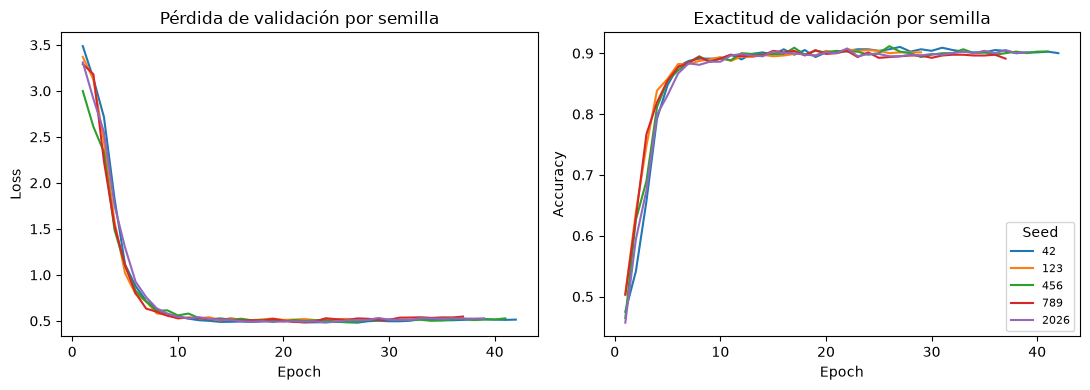

✓ Media, desviación estándar muestral, mínimo y máximo guardados


In [13]:
metric_columns = [
    "cross_entropy", "top_1_accuracy", "top_3_accuracy", "top_5_accuracy",
    "macro_precision", "macro_recall", "macro_f1",
    "weighted_precision", "weighted_recall", "weighted_f1",
    "balanced_accuracy", "matthews_correlation_coefficient",
    "macro_auroc_ovr", "weighted_auroc_ovr",
    "macro_auprc_ovr", "weighted_auprc_ovr",
    "multiclass_brier_score", "expected_calibration_error",
]
aggregate_rows = []
for metric in metric_columns:
    values = seed_metrics[metric].astype(float)
    aggregate_rows.append({
        "metric": metric,
        "mean": float(values.mean()),
        "std": float(values.std(ddof=1)),
        "min": float(values.min()),
        "max": float(values.max()),
    })
seed_aggregate = pd.DataFrame(aggregate_rows)
seed_aggregate.to_csv(RESULTS_DIR / "SEED_AGGREGATE_METRICS.csv", index=False)
display(seed_aggregate.style.format({c: "{:.4f}" for c in ["mean", "std", "min", "max"]}))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for run_seed, frame in all_histories.groupby("seed"):
    axes[0].plot(frame["epoch"], frame["val_loss"], label=str(run_seed))
    axes[1].plot(frame["epoch"], frame["val_accuracy"], label=str(run_seed))
axes[0].set(title="Pérdida de validación por semilla", xlabel="Epoch", ylabel="Loss")
axes[1].set(title="Exactitud de validación por semilla", xlabel="Epoch", ylabel="Accuracy")
axes[1].legend(title="Seed", fontsize=8)
fig.tight_layout()
plt.show()
print("✓ Media, desviación estándar muestral, mínimo y máximo guardados")


## Diagnóstico visual de estabilidad mediante boxplots

Estos boxplots complementan la tabla de media, desviación estándar, mínimo y máximo. Cada punto representa una de las cinco semillas; el rombo rojo representa la media. Una arquitectura candidata sólida debe combinar **rendimiento central alto** con **dispersión baja**, especialmente en `macro F1`, que concede el mismo peso a cada mineral.

Con solo cinco ejecuciones, el boxplot debe interpretarse junto con los puntos individuales: describe la estabilidad observada, pero no sustituye un intervalo de confianza ni una prueba estadística entre arquitecturas. La comparación del modelo ganador debe hacerse sobre el mismo split y usando las cinco semillas completas, nunca escogiendo únicamente la mejor ejecución.


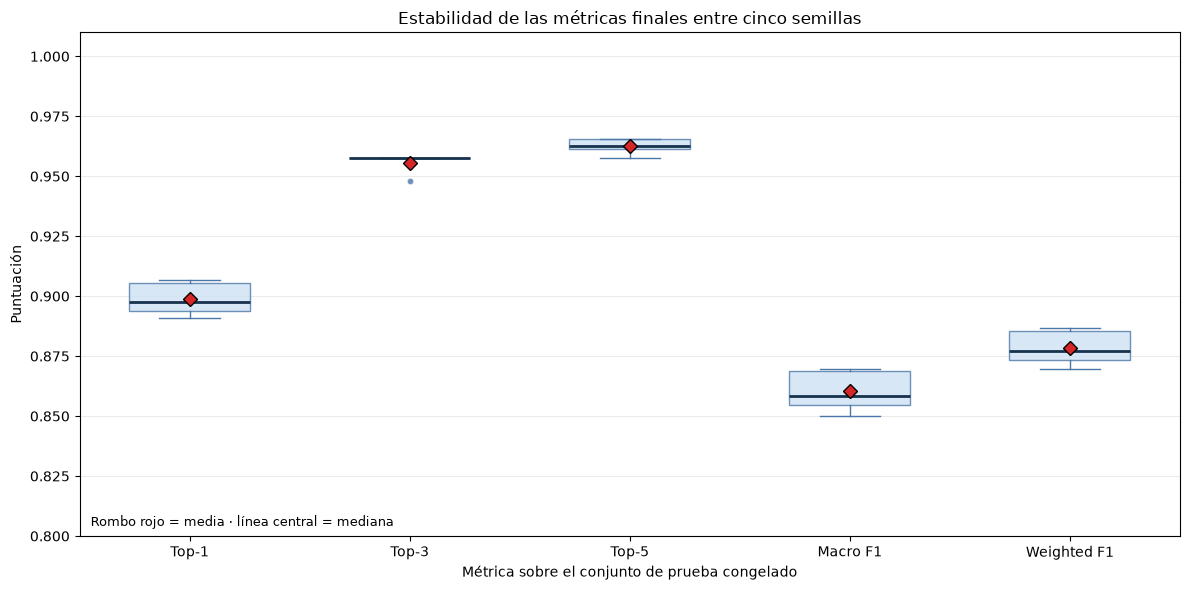

Resumen para comparar rendimiento medio y estabilidad:


,metric,mean,std,min,max,range
0,top_1_accuracy,0.8989,0.0071,0.8910,0.9069,0.0160
1,top_3_accuracy,0.9556,0.0042,0.9481,0.9574,0.0093
2,top_5_accuracy,0.9625,0.0033,0.9574,0.9654,0.0080
3,macro_f1,0.8603,0.0088,0.8500,0.8697,0.0198
4,weighted_f1,0.8784,0.0075,0.8695,0.8867,0.0171


In [14]:
# Métricas principales para comparar rendimiento y estabilidad entre semillas
stability_columns = [
    "top_1_accuracy",
    "top_3_accuracy",
    "top_5_accuracy",
    "macro_f1",
    "weighted_f1",
]

stability_labels = [
    "Top-1",
    "Top-3",
    "Top-5",
    "Macro F1",
    "Weighted F1",
]

stability_values = [
    seed_metrics[column].astype(float).to_numpy()
    for column in stability_columns
]

fig, ax = plt.subplots(figsize=(12, 6))

box = ax.boxplot(
    stability_values,
    tick_labels=stability_labels,
    widths=0.55,
    patch_artist=True,
    showmeans=True,
    meanprops={
        "marker": "D",
        "markerfacecolor": "#d62728",
        "markeredgecolor": "black",
        "markersize": 7,
    },
    medianprops={
        "color": "#17324d",
        "linewidth": 2,
    },
    whiskerprops={"color": "#4c78a8"},
    capprops={"color": "#4c78a8"},
    flierprops={
        "marker": "o",
        "markerfacecolor": "#4c78a8",
        "markeredgecolor": "white",
        "markersize": 5,
        "alpha": 0.8,
    },
)

for patch in box["boxes"]:
    patch.set_facecolor("#cfe2f3")
    patch.set_edgecolor("#4c78a8")
    patch.set_alpha(0.8)

lower_limit = max(
    0.0,
    min(float(values.min()) for values in stability_values) - 0.05,
)

ax.set_ylim(lower_limit, 1.01)
ax.set_title("Estabilidad de las métricas finales entre cinco semillas")
ax.set_xlabel("Métrica sobre el conjunto de prueba congelado")
ax.set_ylabel("Puntuación")
ax.grid(axis="y", alpha=0.25)

ax.text(
    0.01,
    0.02,
    "Rombo rojo = media · línea central = mediana",
    transform=ax.transAxes,
    fontsize=9,
)

fig.tight_layout()
plt.show()

# Resumen estadístico mostrado debajo del gráfico
stability_summary = pd.DataFrame({
    "metric": stability_columns,
    "mean": [values.mean() for values in stability_values],
    "std": [values.std(ddof=1) for values in stability_values],
    "min": [values.min() for values in stability_values],
    "max": [values.max() for values in stability_values],
    "range": [
        values.max() - values.min()
        for values in stability_values
    ],
})

print("Resumen para comparar rendimiento medio y estabilidad:")

display(
    stability_summary.style.format({
        "mean": "{:.4f}",
        "std": "{:.4f}",
        "min": "{:.4f}",
        "max": "{:.4f}",
        "range": "{:.4f}",
    }).background_gradient(
        subset=["std", "range"],
        cmap="YlOrRd",
    )
)

## 14. Diagnósticos de estabilidad sobre el conjunto de prueba congelado

Esta sección conserva predicciones detalladas para analizar errores, clases difíciles y variabilidad entre semillas. Las métricas del test se calculan después de finalizar cada entrenamiento y se utilizan únicamente para evaluación científica.

Los resultados de consenso o por dominio son diagnósticos complementarios: no sustituyen las métricas individuales ni se emplean para escoger retrospectivamente la mejor semilla.

En este notebook se guarda además una predicción de consenso promedio para facilitar el análisis de errores. Este promedio no se presenta como un ensemble validado ni reemplaza el promedio de métricas de las cinco ejecuciones.

In [15]:
# Se guarda el consenso por espectro sin designar una semilla «mejor».
stacked_probabilities = np.stack([seed_probabilities[s] for s in SEEDS], axis=0)
mean_probabilities = stacked_probabilities.mean(axis=0)
consensus_pred = mean_probabilities.argmax(axis=1)
consensus = split_manifest.iloc[test_idx][["spectrum_id", "filepath", "source_id", "label"]].reset_index(drop=True)
consensus["consensus_predicted_label"] = class_names[consensus_pred]
consensus["consensus_correct"] = consensus_pred == y_test
consensus["prediction_agreement_fraction"] = np.mean(
    np.stack([seed_probabilities[s].argmax(axis=1) for s in SEEDS]) == consensus_pred[None, :], axis=0
)
consensus.to_csv(RESULTS_DIR / "SEED_CONSENSUS_TEST_PREDICTIONS.csv", index=False)
print("✓ Predicciones de consenso guardadas solo para análisis de errores; no reemplazan las métricas por semilla")



[SOLO PANTALLA] raman_excellent_unoriented_fixed_split_5_seeds/results/SEED_CONSENSUS_TEST_PREDICTIONS.csv | dimensiones: (752, 7)


,spectrum_id,filepath,source_id,label,consensus_predicted_label,consensus_correct,prediction_agreement_fraction
0,S000024,excellent_unoriented.zip::Actinolite__R050336_...,R050336,Actinolite,Actinolite,True,1.0
1,S000025,excellent_unoriented.zip::Actinolite__R050336_...,R050336,Actinolite,Actinolite,True,1.0
2,S000026,excellent_unoriented.zip::Actinolite__R050336_...,R050336,Actinolite,Actinolite,True,1.0
3,S000027,excellent_unoriented.zip::Actinolite__R050336_...,R050336,Actinolite,Actinolite,True,1.0
4,S000028,excellent_unoriented.zip::Actinolite__R050336_...,R050336,Actinolite,Actinolite,True,0.8
5,S000029,excellent_unoriented.zip::Actinolite__R050336_...,R050336,Actinolite,Actinolite,True,0.8
6,S000056,excellent_unoriented.zip::Adamite__R060593__Ra...,R060593,Adamite,Adamite,True,1.0
7,S000057,excellent_unoriented.zip::Adamite__R060593__Ra...,R060593,Adamite,Adamite,True,1.0
8,S000058,excellent_unoriented.zip::Adamite__R060593__Ra...,R060593,Adamite,Adamite,True,1.0
9,S000059,excellent_unoriented.zip::Adamite__R060593__Ra...,R060593,Adamite,Adamite,True,1.0


✓ Predicciones de consenso guardadas solo para análisis de errores; no reemplazan las métricas por semilla


## 15. Salvaguardas finales y resumen del experimento

Se verifican de nuevo las condiciones que sostienen la validez del protocolo: ausencia de fuentes compartidas entre particiones, conservación de los espectros de validación y prueba, presencia de todas las ejecuciones previstas y coherencia de los archivos exportados.

El resumen registra la configuración necesaria para interpretar y reproducir los resultados. Si alguna salvaguarda falla, el notebook se detiene en lugar de presentar como válido un experimento con posible fuga de información o ejecución incompleta.

In [16]:
split_counts = {"train": int(len(train_idx)), "validation": int(len(val_idx)), "test": int(len(test_idx))}
partition_sources = {
    "train": set(metadata.loc[train_idx, "source_id"]),
    "validation": set(metadata.loc[val_idx, "source_id"]),
    "test": set(metadata.loc[test_idx, "source_id"]),
}
overlap_audit = pd.DataFrame([
    {"partition_a": "train", "partition_b": "validation", "source_overlap": len(partition_sources["train"] & partition_sources["validation"])},
    {"partition_a": "train", "partition_b": "test", "source_overlap": len(partition_sources["train"] & partition_sources["test"])},
    {"partition_a": "validation", "partition_b": "test", "source_overlap": len(partition_sources["validation"] & partition_sources["test"])},
])
assert (overlap_audit["source_overlap"] == 0).all()
overlap_audit.to_csv(RESULTS_DIR / "SOURCE_OVERLAP_AUDIT.csv", index=False)

summary = {
    "notebook_version": "FIXED_SPLIT_5_SEEDS_FINAL_2026_08_10",
    "training_seeds": SEEDS,
    "split_is_fixed_across_seeds": True,
    "split": split_counts,
    "source_groups_cross_partitions": False,
    "checkpoint_selection": "pérdida mínima de validación calculada independientemente en cada semilla",
    "test_selection_policy": "ninguna semilla se selecciona o descarta usando el test; se informa la media ± desviación estándar muestral de todas las ejecuciones",
    "architecture": parameter_report,
    "augmentation": "desplazamiento aleatorio y ruido gaussiano solo en entrenamiento, con semilla independiente por ejecución",
    "total_training_minutes": float(total_training_minutes),
    "seed_run_metrics": seed_metrics.to_dict(orient="records"),
    "aggregate_metrics": seed_aggregate.to_dict(orient="records"),
}
(RESULTS_DIR / "experiment_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
print("Directorio de resultados:", RESULTS_DIR.resolve())
print("✓ Experimento definitivo de estabilidad con cinco semillas completado")



[SOLO PANTALLA] raman_excellent_unoriented_fixed_split_5_seeds/results/SOURCE_OVERLAP_AUDIT.csv | dimensiones: (3, 3)


,partition_a,partition_b,source_overlap
0,train,validation,0
1,train,test,0
2,validation,test,0


[SOLO PANTALLA] experiment_summary.json:
{
  "notebook_version": "FIXED_SPLIT_5_SEEDS_FINAL_2026_08_10",
  "training_seeds": [
    42,
    123,
    456,
    789,
    2026
  ],
  "split_is_fixed_across_seeds": true,
  "split": {
    "train": 2141,
    "validation": 781,
    "test": 752
  },
  "source_groups_cross_partitions": false,
  "checkpoint_selection": "p\u00e9rdida m\u00ednima de validaci\u00f3n calculada independientemente en cada semilla",
  "test_selection_policy": "ninguna semilla se selecciona o descarta usando el test; se informa la media \u00b1 desviaci\u00f3n est\u00e1ndar muestral de todas las ejecuciones",
  "architecture": {
    "model_name": "pictured_raman_cnn_16_32_64",
    "trainable_parameters": 8622544,
    "total_parameters": 8627280,
    "architecture": "Conv1D 16/k21, 32/k11, 64/k5; Dense 2048; pooled dense features; dropout 0.5"
  },
  "augmentation": "desplazamiento aleatorio y ruido gaussiano solo en entrenamiento, con semilla independiente por ejecuci\u00f

## Interpretación metodológica

El resultado principal debe presentarse como **media ± desviación estándar muestral de las cinco semillas**. No debe seleccionarse ni descartarse una ejecución por su rendimiento en el conjunto de prueba. La comparación entre modelos es válida porque la partición, el preprocesamiento, el aumento de datos, los callbacks y las métricas permanecen congelados dentro del protocolo.

Una diferencia entre weighted F1 y macro F1 indica rendimiento desigual entre clases: las clases con mayor soporte pueden mantener una métrica ponderada alta aunque algunos minerales minoritarios sean difíciles. Top-3 y Top-5 son útiles en un sistema de apoyo a la identificación, pero no reemplazan el análisis de Top-1 y macro F1.

Estos resultados estiman generalización hacia fuentes independientes bajo la distribución representada por el test. No demuestran desempeño universal frente a instrumentos, condiciones o minerales ausentes de RRUFF.

## 16. Diagnóstico exhaustivo del candidato seleccionado para producción

Esta sección caracteriza el checkpoint elegido mediante la **pérdida de validación**, sin usar el test para seleccionarlo. Solo después de congelar esa regla se emplea el conjunto de prueba para describir su comportamiento final.

Se generan los siguientes diagnósticos:

- **Matriz de confusión sin normalizar:** conserva el número absoluto de errores y permite detectar confusiones frecuentes.
- **Matriz normalizada por filas:** cada fila suma uno y muestra qué proporción de cada mineral real se asigna a cada predicción. Resulta más justa para comparar clases con soportes diferentes.
- **Informe por clase:** soporte, precision, recall y F1 para las 255 clases. Las clases sin ejemplos de prueba se conservan con soporte cero, pero no deben interpretarse.
- **Clases más difíciles:** se ordenan por recall entre las clases presentes en test.
- **Pares de confusión:** se excluye la diagonal y se listan los errores real → predicho más frecuentes.
- **Calibración:** compara la confianza softmax con la exactitud observada. Un modelo calibrado debería acertar aproximadamente el 80 % de las veces cuando declara una confianza de 0,80.
- **Curvas ROC y precision–recall representativas:** se muestran pocas clases con soporte suficiente para mantener la figura legible. Las métricas agregadas de AUROC y AUPRC de todas las clases evaluables ya se calculan en cada semilla.

AUROC es complementario porque el esquema one-vs-rest produce muchos negativos por clase. AUPRC es especialmente informativa ante desbalance, aunque su línea base depende de la prevalencia de cada mineral. Ninguna de estas métricas sustituye Top-1, macro F1 ni el análisis de confusiones.



[SOLO PANTALLA] raman_excellent_unoriented_fixed_split_5_seeds/results/production/final_test_predictions.csv | dimensiones: (752, 11)


,spectrum_id,filepath,source_id,label,dataset_subset,true_class_index,predicted_class_index,predicted_label,correct,confidence,true_class_probability
0,S000024,excellent_unoriented.zip::Actinolite__R050336_...,R050336,Actinolite,excellent_unoriented,0,0,Actinolite,True,0.823097,0.823097
1,S000025,excellent_unoriented.zip::Actinolite__R050336_...,R050336,Actinolite,excellent_unoriented,0,0,Actinolite,True,0.928945,0.928945
2,S000026,excellent_unoriented.zip::Actinolite__R050336_...,R050336,Actinolite,excellent_unoriented,0,0,Actinolite,True,0.815861,0.815861
3,S000027,excellent_unoriented.zip::Actinolite__R050336_...,R050336,Actinolite,excellent_unoriented,0,0,Actinolite,True,0.900530,0.900530
4,S000028,excellent_unoriented.zip::Actinolite__R050336_...,R050336,Actinolite,excellent_unoriented,0,0,Actinolite,True,0.386617,0.386617
5,S000029,excellent_unoriented.zip::Actinolite__R050336_...,R050336,Actinolite,excellent_unoriented,0,0,Actinolite,True,0.532434,0.532434
6,S000056,excellent_unoriented.zip::Adamite__R060593__Ra...,R060593,Adamite,excellent_unoriented,1,1,Adamite,True,0.999865,0.999865
7,S000057,excellent_unoriented.zip::Adamite__R060593__Ra...,R060593,Adamite,excellent_unoriented,1,1,Adamite,True,0.999812,0.999812
8,S000058,excellent_unoriented.zip::Adamite__R060593__Ra...,R060593,Adamite,excellent_unoriented,1,1,Adamite,True,0.999946,0.999946
9,S000059,excellent_unoriented.zip::Adamite__R060593__Ra...,R060593,Adamite,excellent_unoriented,1,1,Adamite,True,0.999926,0.999926



[SOLO PANTALLA] raman_excellent_unoriented_fixed_split_5_seeds/results/production/final_per_class_metrics.csv | dimensiones: (208, 6)


,class_index,label,precision,recall,f1-score,support
0,0,Actinolite,1.000000,1.000000,1.000000,6.0
1,1,Adamite,1.000000,1.000000,1.000000,4.0
2,2,Aegirine,1.000000,1.000000,1.000000,5.0
3,3,Agardite-(Y),0.666667,1.000000,0.800000,2.0
4,4,Albite,1.000000,1.000000,1.000000,4.0
5,5,Alluaudite,1.000000,1.000000,1.000000,4.0
6,6,Almandine,1.000000,1.000000,1.000000,2.0
7,7,Alum-(K),0.600000,1.000000,0.750000,6.0
8,8,Andalusite,1.000000,1.000000,1.000000,4.0
9,9,Andradite,0.000000,0.000000,0.000000,4.0



[SOLO PANTALLA] raman_excellent_unoriented_fixed_split_5_seeds/results/production/final_confusion_matrix_counts.csv | dimensiones: (208, 208)


,Actinolite,Adamite,Aegirine,Agardite-(Y),Albite,Alluaudite,Almandine,Alum-(K),Andalusite,Andradite,...,Vuonnemite,Wendwilsonite,Whewellite,Willemite,Witherite,Wolfeite,Wulfenite,Xenotime-(Y),Zincite,Zircon
Actinolite,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Adamite,0,4,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Aegirine,0,0,5,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Agardite-(Y),0,0,0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Albite,0,0,0,0,4,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Alluaudite,0,0,0,0,0,4,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Almandine,0,0,0,0,0,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Alum-(K),0,0,0,0,0,0,0,6,0,0,...,0,0,0,0,0,0,0,0,0,0
Andalusite,0,0,0,0,0,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
Andradite,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



[SOLO PANTALLA] raman_excellent_unoriented_fixed_split_5_seeds/results/production/final_confusion_matrix_normalized.csv | dimensiones: (208, 208)


,Actinolite,Adamite,Aegirine,Agardite-(Y),Albite,Alluaudite,Almandine,Alum-(K),Andalusite,Andradite,...,Vuonnemite,Wendwilsonite,Whewellite,Willemite,Witherite,Wolfeite,Wulfenite,Xenotime-(Y),Zincite,Zircon
Actinolite,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Adamite,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Aegirine,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Agardite-(Y),0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Albite,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Alluaudite,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Almandine,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Alum-(K),0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Andalusite,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Andradite,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


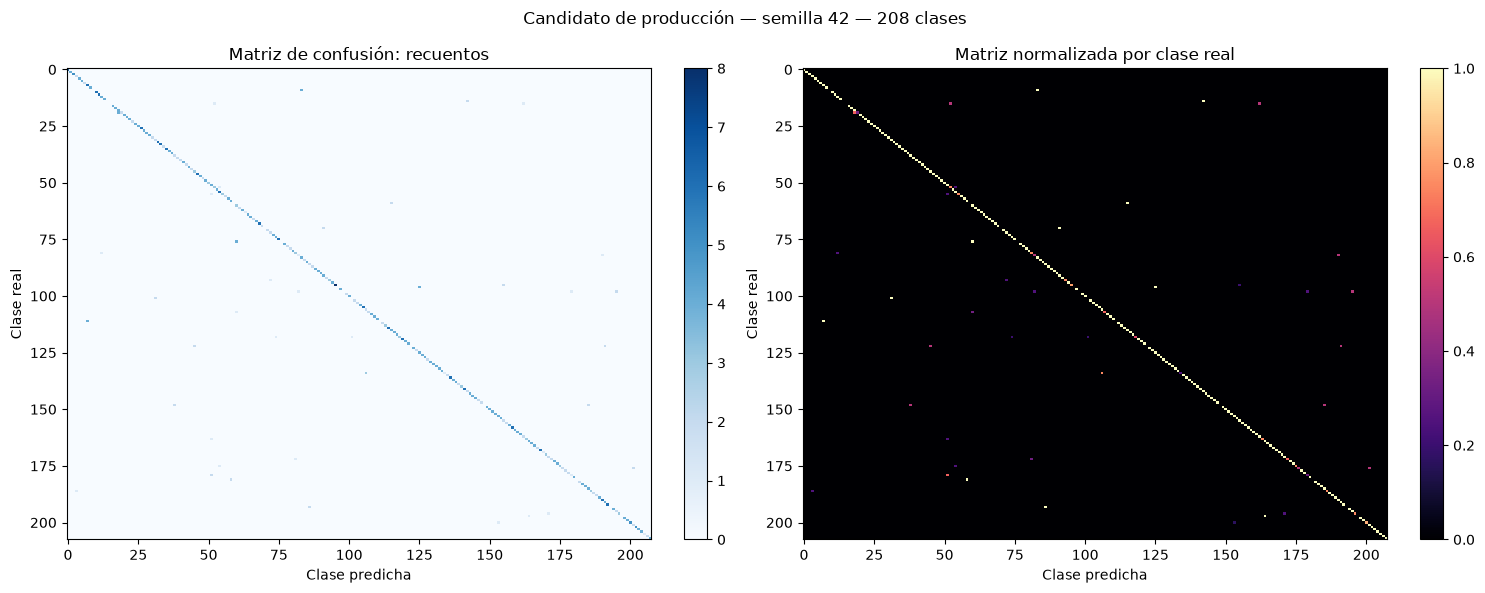


[SOLO PANTALLA] raman_excellent_unoriented_fixed_split_5_seeds/results/production/final_confusion_pairs.csv | dimensiones: (39, 6)


,true_class_index,true_label,predicted_class_index,predicted_label,count,fraction_of_true_class
0,9,Andradite,83,Grossular,4,1.000000
1,76,Foitite,60,Elbaite,4,1.000000
2,96,Jarosite,125,Natrojarosite,4,1.000000
3,111,Mascagnite,7,Alum-(K),4,1.000000
4,19,Axinite-(Mn),18,Axinite-(Fe),4,0.666667
5,134,Pargasite,106,Magnetite,3,0.750000
6,14,Argentopyrite,142,Pyrite,2,1.000000
7,59,Duftite,115,Mimetite,2,1.000000
8,70,Ferberite,91,Hubnerite,2,1.000000
9,101,Langite,31,Brochantite,2,1.000000



[SOLO PANTALLA] raman_excellent_unoriented_fixed_split_5_seeds/results/production/final_30_hardest_classes.csv | dimensiones: (30, 6)


,class_index,label,precision,recall,f1-score,support
9,9,Andradite,0.00,0.000000,0.000000,4.0
76,76,Foitite,0.00,0.000000,0.000000,4.0
96,96,Jarosite,0.00,0.000000,0.000000,4.0
98,98,Kryzhanovskite,0.00,0.000000,0.000000,4.0
111,111,Mascagnite,0.00,0.000000,0.000000,4.0
122,122,Mottramite,0.00,0.000000,0.000000,4.0
148,148,Retgersite,0.00,0.000000,0.000000,4.0
14,14,Argentopyrite,0.00,0.000000,0.000000,2.0
15,15,Armalcolite,0.00,0.000000,0.000000,2.0
59,59,Duftite,0.00,0.000000,0.000000,2.0


,class_index,label,precision,recall,f1-score,support
9,9,Andradite,0.0,0.0,0.0,4.0
76,76,Foitite,0.0,0.0,0.0,4.0
96,96,Jarosite,0.0,0.0,0.0,4.0
98,98,Kryzhanovskite,0.0,0.0,0.0,4.0
111,111,Mascagnite,0.0,0.0,0.0,4.0
122,122,Mottramite,0.0,0.0,0.0,4.0
148,148,Retgersite,0.0,0.0,0.0,4.0
14,14,Argentopyrite,0.0,0.0,0.0,2.0
15,15,Armalcolite,0.0,0.0,0.0,2.0
59,59,Duftite,0.0,0.0,0.0,2.0


,true_class_index,true_label,predicted_class_index,predicted_label,count,fraction_of_true_class
0,9,Andradite,83,Grossular,4,1.000000
1,76,Foitite,60,Elbaite,4,1.000000
2,96,Jarosite,125,Natrojarosite,4,1.000000
3,111,Mascagnite,7,Alum-(K),4,1.000000
4,19,Axinite-(Mn),18,Axinite-(Fe),4,0.666667
5,134,Pargasite,106,Magnetite,3,0.750000
6,14,Argentopyrite,142,Pyrite,2,1.000000
7,59,Duftite,115,Mimetite,2,1.000000
8,70,Ferberite,91,Hubnerite,2,1.000000
9,101,Langite,31,Brochantite,2,1.000000



[SOLO PANTALLA] raman_excellent_unoriented_fixed_split_5_seeds/results/production/final_calibration_bins.csv | dimensiones: (10, 5)


,bin_lower,bin_upper,n_spectra,mean_confidence,observed_accuracy
0,0.0,0.1,13,0.072642,0.076923
1,0.1,0.2,16,0.147378,0.312500
2,0.2,0.3,12,0.249995,0.750000
3,0.3,0.4,11,0.359548,0.727273
4,0.4,0.5,10,0.464055,0.700000
5,0.5,0.6,10,0.545939,0.500000
6,0.6,0.7,14,0.652373,0.857143
7,0.7,0.8,23,0.760178,0.826087
8,0.8,0.9,27,0.857035,0.777778
9,0.9,1.0,616,0.990663,0.965909


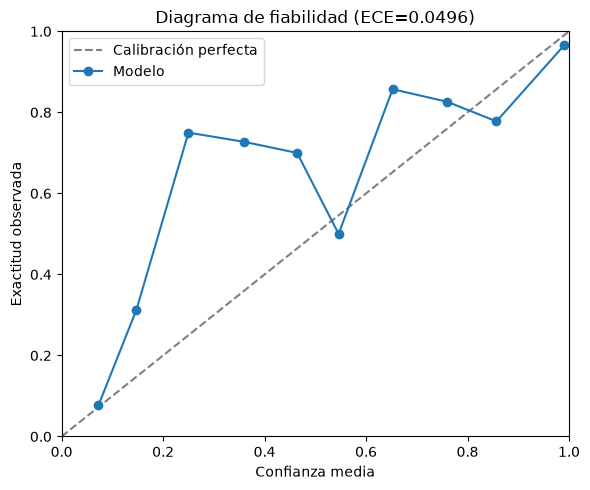

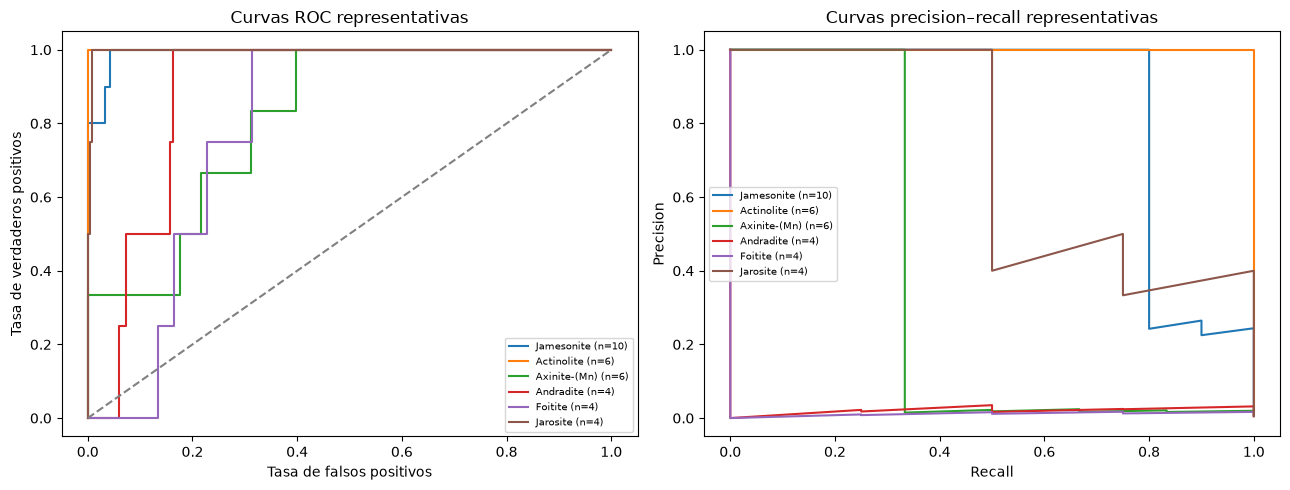

[SOLO PANTALLA] final_test_metrics.json:
{
  "selected_seed": 42,
  "cross_entropy": 0.5591570138931274,
  "top_1_accuracy": 0.9069148936170213,
  "top_3_accuracy": 0.9574468085106383,
  "top_5_accuracy": 0.9654255319148937,
  "macro_precision": 0.8643372252747253,
  "macro_recall": 0.8965544871794872,
  "macro_f1": 0.8689591124687279,
  "weighted_precision": 0.8882108029381964,
  "weighted_recall": 0.9069148936170213,
  "weighted_f1": 0.8866546426386852,
  "balanced_accuracy": 0.8965544871794872,
  "matthews_correlation_coefficient": 0.9067010626305653,
  "macro_auroc_ovr": 0.994512101366285,
  "weighted_auroc_ovr": 0.9941553820596154,
  "macro_auprc_ovr": 0.9310886604305899,
  "weighted_auprc_ovr": 0.9358266900770735,
  "multiclass_brier_score": 0.1556532382965088,
  "expected_calibration_error": 0.049644167990760574,
  "ovr_evaluable_classes": 208
}
✓ Diagnóstico final guardado para el candidato seleccionado por validación: semilla 42


In [17]:
# Se reproduce la regla de selección basada únicamente en validación.
diagnostic_winner = (
    all_histories[np.isfinite(all_histories["val_loss"])]
    .sort_values(["val_loss", "epoch", "seed"], ascending=[True, True, True])
    .iloc[0]
)
diagnostic_seed = int(diagnostic_winner["seed"])
final_probabilities = seed_probabilities[diagnostic_seed]
final_predictions = final_probabilities.argmax(axis=1)
final_metrics = calculate_metrics(y_test, final_probabilities)

PRODUCTION_DIR = RESULTS_DIR / "production"

# Predicciones individuales para trazabilidad y futuros análisis de errores.
available_metadata = [
    c for c in ["spectrum_id", "filepath", "source_id", "label", "dataset_subset"]
    if c in split_manifest.columns
]
final_prediction_table = split_manifest.iloc[test_idx][available_metadata].reset_index(drop=True).copy()
final_prediction_table["true_class_index"] = y_test
final_prediction_table["predicted_class_index"] = final_predictions
final_prediction_table["predicted_label"] = class_names[final_predictions]
final_prediction_table["correct"] = final_predictions == y_test
final_prediction_table["confidence"] = final_probabilities.max(axis=1)
final_prediction_table["true_class_probability"] = final_probabilities[np.arange(len(y_test)), y_test]
final_prediction_table.to_csv(PRODUCTION_DIR / "final_test_predictions.csv", index=False)

# Informe completo por clase, incluyendo explícitamente las clases sin soporte en test.
report = classification_report(
    y_test, final_predictions, labels=np.arange(n_classes), target_names=class_names,
    output_dict=True, zero_division=0,
)
per_class_report = pd.DataFrame(report).T.iloc[:n_classes].reset_index(names="label")
per_class_report.insert(0, "class_index", np.arange(n_classes))
per_class_report.to_csv(PRODUCTION_DIR / "final_per_class_metrics.csv", index=False)

# Matrices de confusión absoluta y normalizada por clase real.
cm_counts = confusion_matrix(y_test, final_predictions, labels=np.arange(n_classes))
row_totals = cm_counts.sum(axis=1, keepdims=True)
cm_normalized = np.divide(
    cm_counts, row_totals, out=np.zeros_like(cm_counts, dtype=float), where=row_totals != 0
)
pd.DataFrame(cm_counts, index=class_names, columns=class_names).to_csv(
    PRODUCTION_DIR / "final_confusion_matrix_counts.csv"
)
pd.DataFrame(cm_normalized, index=class_names, columns=class_names).to_csv(
    PRODUCTION_DIR / "final_confusion_matrix_normalized.csv"
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
im0 = axes[0].imshow(cm_counts, aspect="auto", interpolation="nearest", cmap="Blues")
axes[0].set(title="Matriz de confusión: recuentos", xlabel="Clase predicha", ylabel="Clase real")
fig.colorbar(im0, ax=axes[0], fraction=0.046)
im1 = axes[1].imshow(cm_normalized, aspect="auto", interpolation="nearest", cmap="magma", vmin=0, vmax=1)
axes[1].set(title="Matriz normalizada por clase real", xlabel="Clase predicha", ylabel="Clase real")
fig.colorbar(im1, ax=axes[1], fraction=0.046)
fig.suptitle(f"Candidato de producción — semilla {diagnostic_seed} — {n_classes} clases")
fig.tight_layout()
plt.show()

# Confusiones fuera de la diagonal, ordenadas por frecuencia absoluta.
confusion_rows = []
for true_index, predicted_index in np.argwhere(cm_counts > 0):
    if true_index != predicted_index:
        confusion_rows.append({
            "true_class_index": int(true_index),
            "true_label": class_names[true_index],
            "predicted_class_index": int(predicted_index),
            "predicted_label": class_names[predicted_index],
            "count": int(cm_counts[true_index, predicted_index]),
            "fraction_of_true_class": float(cm_normalized[true_index, predicted_index]),
        })
top_confusions = pd.DataFrame(confusion_rows)
if not top_confusions.empty:
    top_confusions = top_confusions.sort_values(
        ["count", "fraction_of_true_class"], ascending=False
    ).reset_index(drop=True)
top_confusions.to_csv(PRODUCTION_DIR / "final_confusion_pairs.csv", index=False)

evaluable_classes = per_class_report[per_class_report["support"] > 0].copy()
hardest_classes = evaluable_classes.sort_values(
    ["recall", "f1-score", "support"], ascending=[True, True, False]
).head(30)
hardest_classes.to_csv(PRODUCTION_DIR / "final_30_hardest_classes.csv", index=False)
display(hardest_classes.head(15))
display(top_confusions.head(20) if not top_confusions.empty else pd.DataFrame())

# Diagrama de fiabilidad para la confianza de la clase elegida.
confidence = final_probabilities.max(axis=1)
correctness = (final_predictions == y_test).astype(float)
bin_edges = np.linspace(0.0, 1.0, 11)
bin_ids = np.clip(np.digitize(confidence, bin_edges[1:-1], right=True), 0, 9)
calibration_rows = []
for bin_index in range(10):
    mask = bin_ids == bin_index
    calibration_rows.append({
        "bin_lower": float(bin_edges[bin_index]),
        "bin_upper": float(bin_edges[bin_index + 1]),
        "n_spectra": int(mask.sum()),
        "mean_confidence": float(confidence[mask].mean()) if mask.any() else np.nan,
        "observed_accuracy": float(correctness[mask].mean()) if mask.any() else np.nan,
    })
calibration_table = pd.DataFrame(calibration_rows)
calibration_table.to_csv(PRODUCTION_DIR / "final_calibration_bins.csv", index=False)

fig, ax = plt.subplots(figsize=(6, 5))
valid_bins = calibration_table[calibration_table["n_spectra"] > 0]
ax.plot([0, 1], [0, 1], "--", color="gray", label="Calibración perfecta")
ax.plot(valid_bins["mean_confidence"], valid_bins["observed_accuracy"], "o-", label="Modelo")
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="Confianza media", ylabel="Exactitud observada",
       title=f"Diagrama de fiabilidad (ECE={final_metrics['expected_calibration_error']:.4f})")
ax.legend()
fig.tight_layout()
plt.show()

# Curvas de un subconjunto legible: tres clases con mayor soporte y tres difíciles.
from sklearn.metrics import precision_recall_curve, roc_curve
representative_indices = []
support_order = evaluable_classes.sort_values("support", ascending=False)["class_index"].astype(int).tolist()
hard_order = hardest_classes["class_index"].astype(int).tolist()
for class_index in support_order[:3] + hard_order:
    binary_truth = (y_test == class_index).astype(int)
    if binary_truth.min() != binary_truth.max() and class_index not in representative_indices:
        representative_indices.append(class_index)
    if len(representative_indices) == 6:
        break

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for class_index in representative_indices:
    binary_truth = (y_test == class_index).astype(int)
    fpr, tpr, _ = roc_curve(binary_truth, final_probabilities[:, class_index])
    precision_curve, recall_curve, _ = precision_recall_curve(binary_truth, final_probabilities[:, class_index])
    label = f"{class_names[class_index]} (n={int(binary_truth.sum())})"
    axes[0].plot(fpr, tpr, label=label)
    axes[1].plot(recall_curve, precision_curve, label=label)
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set(xlabel="Tasa de falsos positivos", ylabel="Tasa de verdaderos positivos", title="Curvas ROC representativas")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Curvas precision–recall representativas")
for ax in axes:
    ax.legend(fontsize=7)
fig.tight_layout()
plt.show()

(PRODUCTION_DIR / "final_test_metrics.json").write_text(
    json.dumps({"selected_seed": diagnostic_seed, **final_metrics}, indent=2), encoding="utf-8"
)
print(f"✓ Diagnóstico final guardado para el candidato seleccionado por validación: semilla {diagnostic_seed}")


## 17. Exportación del candidato para producción seleccionado mediante validación

Como cierre práctico, se exporta un único checkpoint de los cinco entrenamientos. La elección se realiza exclusivamente con la menor pérdida de validación alcanzada por cada semilla; las métricas del test no intervienen. Esta regla evita convertir el test en un segundo conjunto de validación.

El paquete incluye el modelo Keras, el orden exacto de las etiquetas, la rejilla Raman y un contrato de preprocesamiento. En inferencia, un espectro nuevo debe cubrir el intervalo guardado, interpolarse sobre esa rejilla y normalizarse exactamente igual que durante el experimento. Las probabilidades de salida corresponden, en el mismo orden, a `class_labels.csv`.

Este archivo es un **candidato de despliegue**, no una garantía de validez clínica, industrial o universal. Antes de un uso real debe validarse con espectros externos representativos del instrumento y del contexto de aplicación, vigilar entradas fuera de distribución y conservar una revisión experta.

El paquete final incorpora también todos los diagnósticos del test generados en la sección anterior. Estos resultados documentan el modelo ya seleccionado; no participan en su elección.


In [18]:
# Se selecciona y exporta el candidato para producción utilizando exclusivamente validación.
required_history_columns = {"seed", "epoch", "val_loss"}
missing_history_columns = required_history_columns - set(all_histories.columns)
if missing_history_columns:
    raise RuntimeError(f"Faltan columnas del historial necesarias para seleccionar el modelo de producción: {sorted(missing_history_columns)}")

finite_validation = all_histories[np.isfinite(all_histories["val_loss"])].copy()
if finite_validation.empty:
    raise RuntimeError("No existe una pérdida de validación finita; no se puede seleccionar el modelo para producción.")

# Stable tie-breaks: lower val_loss, then earlier epoch, then lower seed.
winner_row = finite_validation.sort_values(
    ["val_loss", "epoch", "seed"], ascending=[True, True, True]
).iloc[0]
production_seed = int(winner_row["seed"])
production_epoch = int(winner_row["epoch"])
production_val_loss = float(winner_row["val_loss"])
production_val_accuracy = (
    float(winner_row["val_accuracy"])
    if "val_accuracy" in winner_row.index and pd.notna(winner_row["val_accuracy"])
    else None
)

production_model = seed_models[production_seed]
smoke_prob = production_model.predict(X_val[:1], verbose=0)
assert smoke_prob.shape == (1, n_classes) and np.isfinite(smoke_prob).all()
selection_manifest = {
    "selected_seed": production_seed, "selected_best_epoch": production_epoch,
    "selected_validation_loss": production_val_loss, "selected_validation_accuracy": production_val_accuracy,
    "n_classes": int(n_classes), "test_metrics_used_for_selection": False,
    "final_test_metrics_for_reporting_only": final_metrics,
}
display(pd.DataFrame([selection_manifest]).T.rename(columns={0: "value"}))
print(f"✓ Candidato seleccionado en memoria: semilla {production_seed}, época {production_epoch}")
print("No se guardaron modelos, tablas, figuras ni paquetes ZIP.")


E0000 00:00:1786591166.580944  649654 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,value
selected_seed,42
selected_best_epoch,27
selected_validation_loss,0.480675
selected_validation_accuracy,0.910371
n_classes,208
test_metrics_used_for_selection,False
final_test_metrics_for_reporting_only,"{'cross_entropy': 0.5591570138931274, 'top_1_a..."


✓ Candidato seleccionado en memoria: semilla 42, época 27
No se guardaron modelos, tablas, figuras ni paquetes ZIP.
